In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob
import re
from pathlib import Path
from sklearn.metrics import mean_absolute_error, mean_squared_error

# ============================================================
# Nastavení
# ============================================================

DATA_DIR = "."
OUTPUT_DIR = "./plots"
SAVE_PLOTS = True
CSV_SEPARATOR = ";"

Path(OUTPUT_DIR).mkdir(exist_ok=True)

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.grid"] = True


# ============================================================
# Pomocné funkce
# ============================================================

def smape(y_true, y_pred):
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
    mask = denominator != 0

    if mask.sum() == 0:
        return np.nan

    return np.mean(np.abs(y_true[mask] - y_pred[mask]) / denominator[mask]) * 100


def calculate_metrics(df):
    y_true = df["real_total"].astype(float)
    y_pred = df["forecast_total"].astype(float)

    error = y_true - y_pred

    return pd.Series({
        "MAE": mean_absolute_error(y_true, y_pred),
        "MSE": mean_squared_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "sMAPE": smape(y_true, y_pred),
        "MeanError": error.mean(),
        "MaxError": np.abs(error).max()
    })


def save_plot(filename):
    plt.tight_layout()

    if SAVE_PLOTS:
        plt.savefig(f"{OUTPUT_DIR}/{filename}", dpi=300, bbox_inches="tight")

    plt.show()


# ============================================================
# Načtení dat
# ============================================================

pattern = f"{DATA_DIR}/forecast_vs_real_*_h_step_*_days_update_data.csv"
files = glob.glob(pattern)

all_data = []

for file in files:
    match = re.search(r"forecast_vs_real_(\d+)_h_step_(\d+)_days_update_data", file)

    if not match:
        continue

    step_hours = int(match.group(1))
    train_days = int(match.group(2))
    train_samples = int(train_days * 24 / step_hours)

    df = pd.read_csv(file, sep=CSV_SEPARATOR)

    df["step_hours"] = step_hours
    df["train_days"] = train_days
    df["train_samples"] = train_samples

    if "day" in df.columns:
        df["day"] = pd.to_datetime(df["day"])

    df["error"] = df["real_total"] - df["forecast_total"]
    df["abs_error"] = np.abs(df["error"])
    df["squared_error"] = df["error"] ** 2

    all_data.append(df)

data = pd.concat(all_data, ignore_index=True)

print(f"Načteno {len(data)} řádků z {len(files)} souborů.")
display(data.head())

Načteno 231 řádků z 21 souborů.


,Unnamed: 0,day,mape,real_total,forecast_total,abs_error,perc_error,step_hours,train_days,train_samples,error,squared_error
0,0,2026-02-10,3.780939,74965.98775,72575.022530,2390.965220,3.189400,12,120,240,2390.965220,5.716715e+06
1,1,2026-02-11,9.664831,64179.60800,70364.290529,6184.682529,9.636523,12,120,240,-6184.682529,3.825030e+07
2,2,2026-02-12,16.738629,60030.19975,67814.671696,7784.471946,12.967593,12,120,240,-7784.471946,6.059800e+07
3,3,2026-02-13,8.512466,65708.13725,61558.089000,4150.048250,6.315882,12,120,240,4150.048250,1.722290e+07
4,4,2026-02-14,12.090400,78509.39375,68195.532171,10313.861579,13.137105,12,120,240,10313.861579,1.063757e+08


In [2]:
summary = (
    data
    .groupby(["step_hours", "train_days", "train_samples"])
    .apply(calculate_metrics)
    .reset_index()
    .sort_values(["step_hours", "train_days"])
)

display(summary)

summary.to_csv(
    f"{OUTPUT_DIR}/summary_metrics.csv",
    sep=CSV_SEPARATOR,
    index=False
)

C:\Users\hp\AppData\Local\Temp\ipykernel_44292\4208492154.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(calculate_metrics)


,step_hours,train_days,train_samples,MAE,MSE,RMSE,sMAPE,MeanError,MaxError
0,1,15,360,7328.814316,7.617586e+07,8727.878276,9.565855,908.152142,15209.794068
1,1,30,720,4233.606454,2.371539e+07,4869.845185,5.371650,433.630964,7876.131160
2,1,60,1440,6384.278070,5.592137e+07,7478.059099,8.228693,3003.763609,12664.083405
3,2,15,180,8156.042706,7.479011e+07,8648.127312,10.723191,1606.401298,13077.763229
4,2,30,360,5431.529730,4.809980e+07,6935.402008,6.995184,3986.144107,13776.902267
5,2,60,720,6899.034048,6.198938e+07,7873.333787,8.898674,3294.929250,12994.630826
6,4,15,90,11482.845682,1.842583e+08,13574.177611,13.751882,-3092.273547,27983.449341
7,4,30,180,9469.409578,1.687192e+08,12989.195034,12.374123,5792.929686,30138.549245
8,4,60,360,8430.214218,1.117651e+08,10571.900655,11.130019,5417.221481,23695.243242
9,4,90,540,7988.184715,1.082683e+08,10405.206191,10.202589,3764.689475,20901.240181


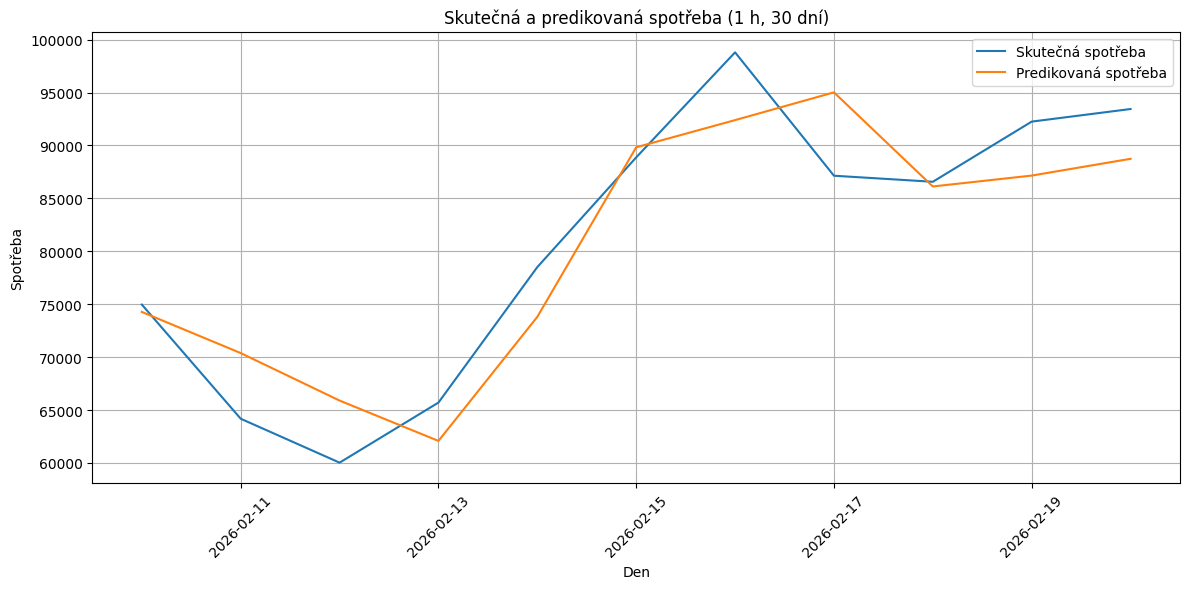

In [3]:
selected_step = 1
selected_days = 30

selected = data[
    (data["step_hours"] == selected_step) &
    (data["train_days"] == selected_days)
].copy()

plt.figure()

plt.plot(selected["day"], selected["real_total"], label="Skutečná spotřeba")
plt.plot(selected["day"], selected["forecast_total"], label="Predikovaná spotřeba")

plt.title(f"Skutečná a predikovaná spotřeba ({selected_step} h, {selected_days} dní)")
plt.xlabel("Den")
plt.ylabel("Spotřeba")
plt.xticks(rotation=45)
plt.legend()

save_plot("real_vs_forecast_selected_model.png")

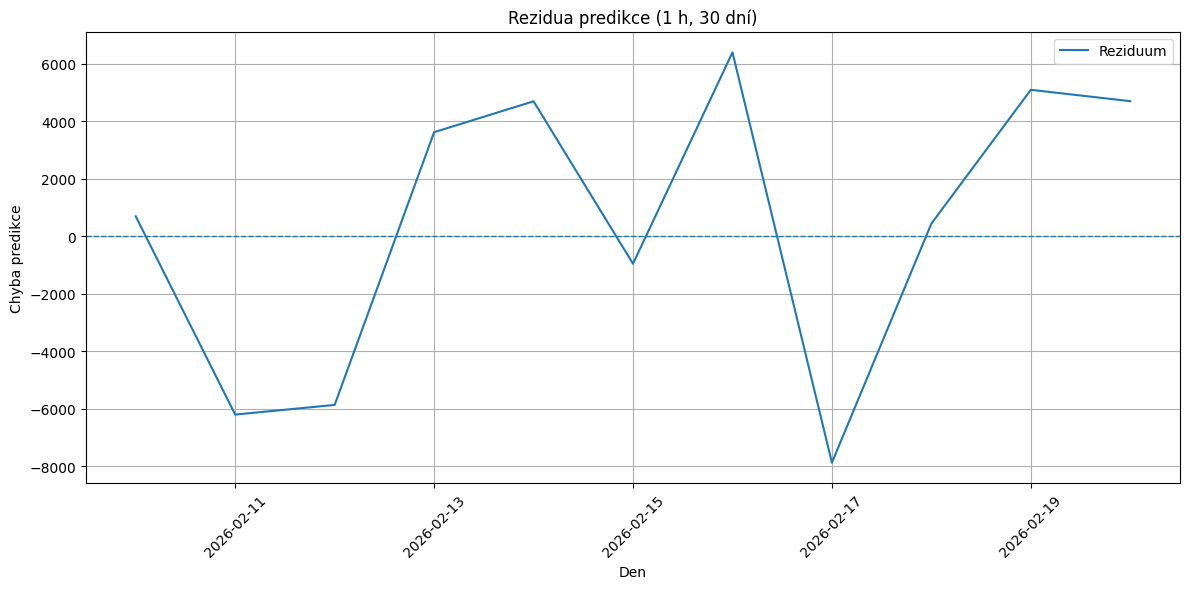

In [4]:
plt.figure()

plt.plot(selected["day"], selected["error"], label="Reziduum")
plt.axhline(0, linestyle="--", linewidth=1)

plt.title(f"Rezidua predikce ({selected_step} h, {selected_days} dní)")
plt.xlabel("Den")
plt.ylabel("Chyba predikce")
plt.xticks(rotation=45)
plt.legend()

save_plot("residuals_selected_model.png")

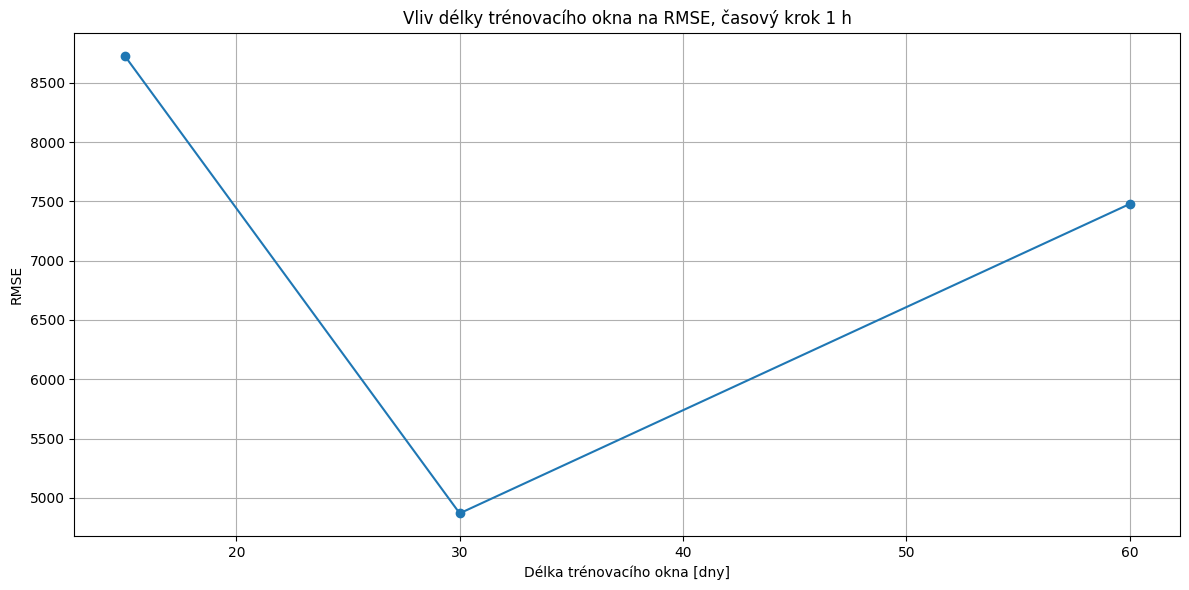

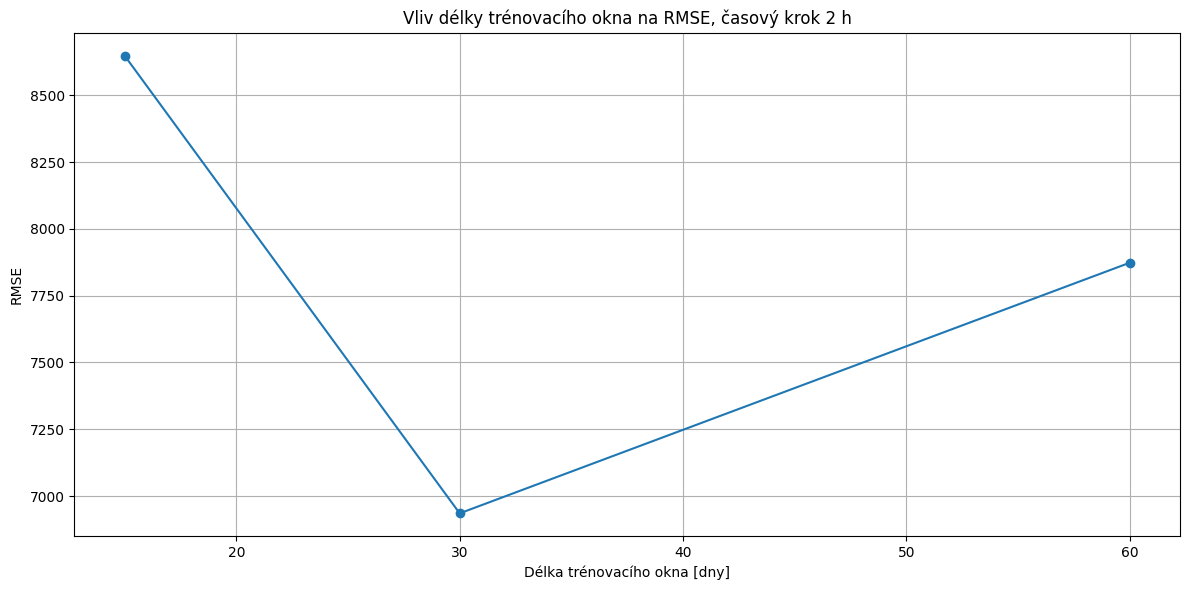

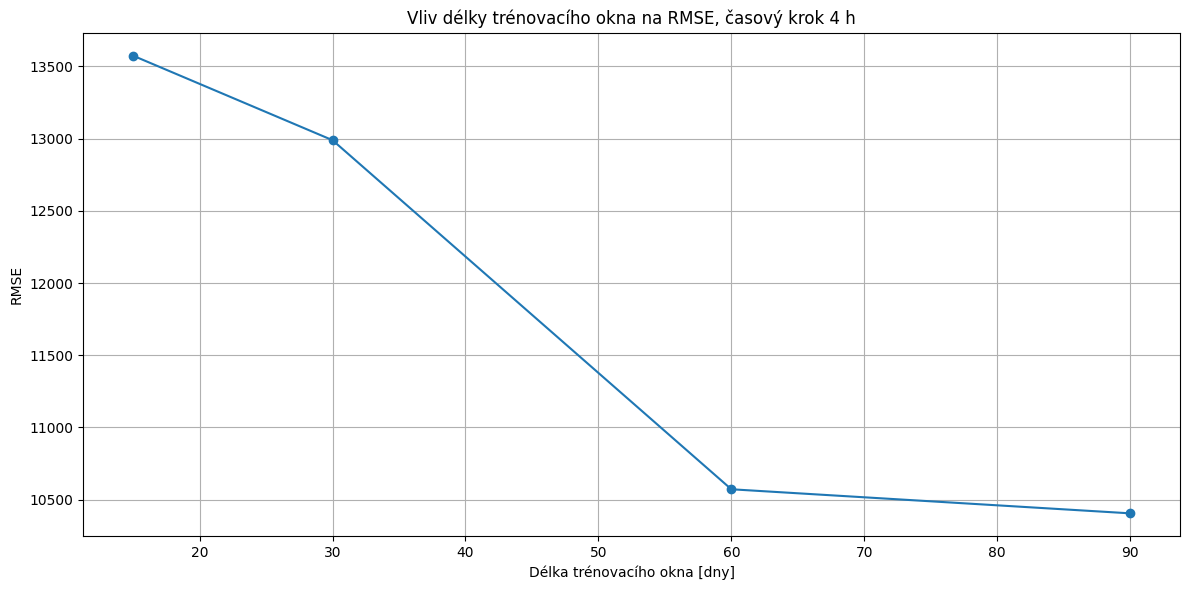

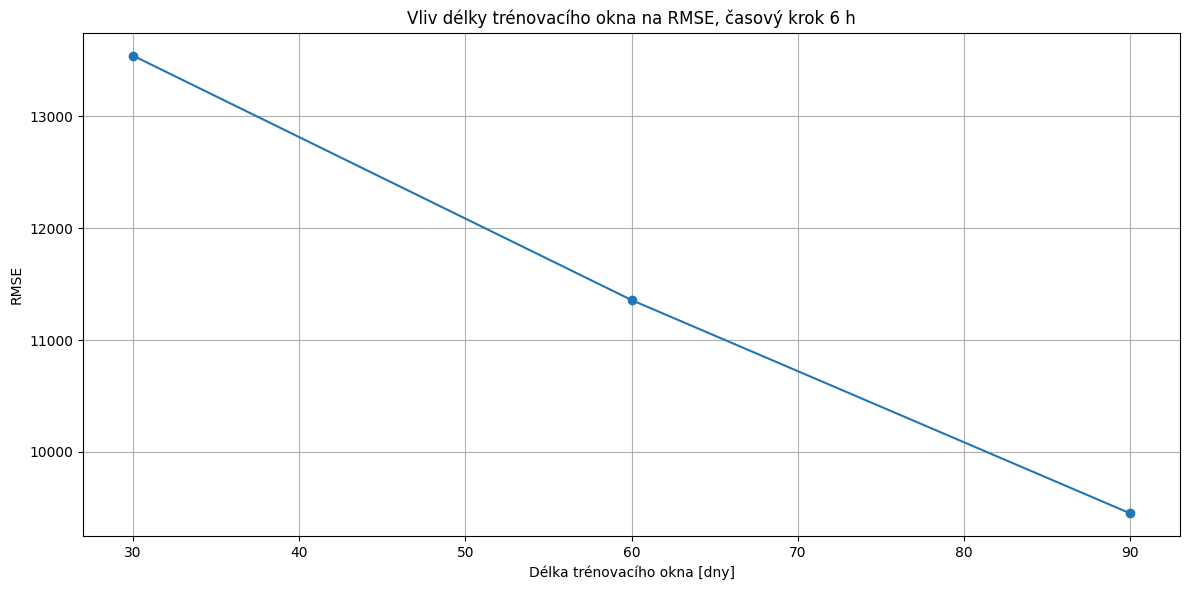

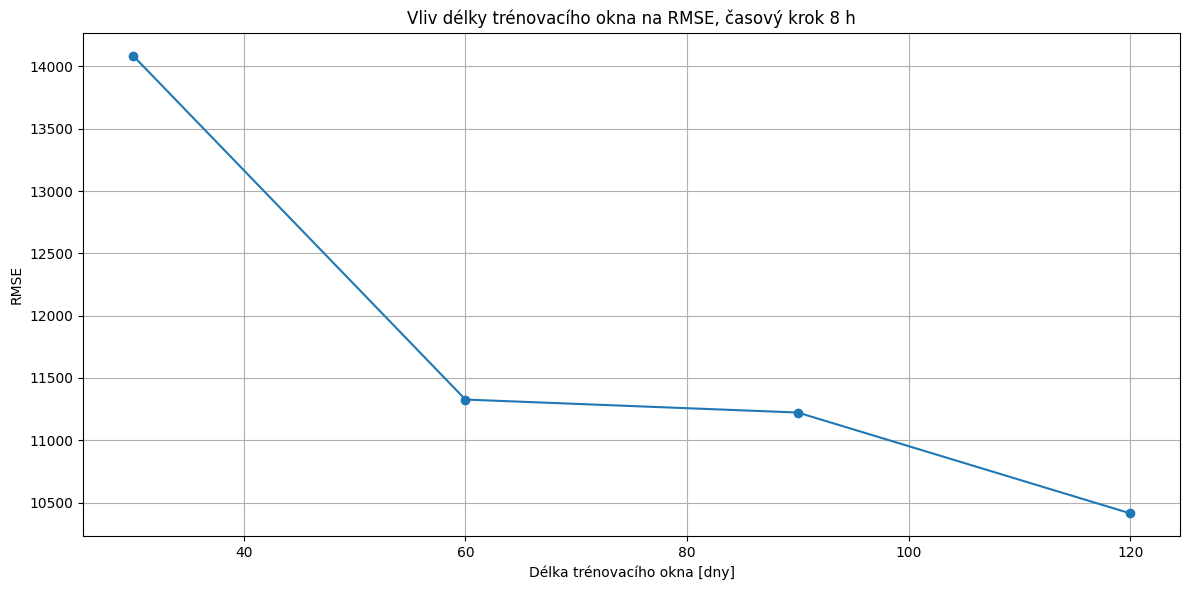

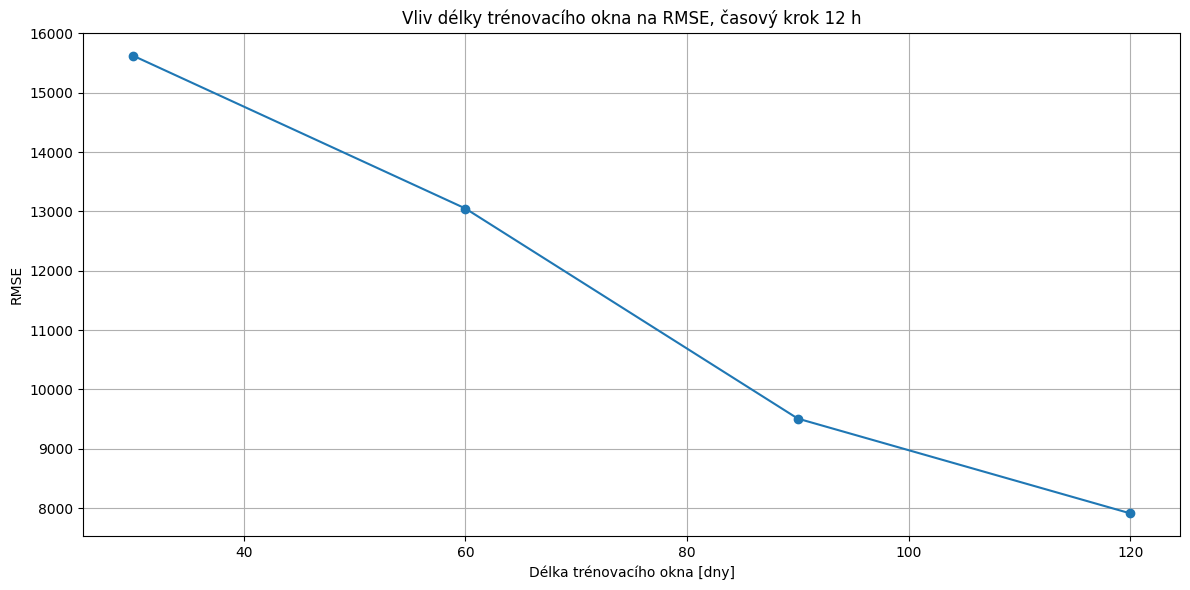

In [6]:
metric = "RMSE"

for step in sorted(summary["step_hours"].unique()):
    step_summary = summary[summary["step_hours"] == step].copy()

    plt.figure()

    plt.plot(
        step_summary["train_days"],
        step_summary[metric],
        marker="o"
    )

    plt.title(f"Vliv délky trénovacího okna na {metric}, časový krok {step} h")
    plt.xlabel("Délka trénovacího okna [dny]")
    plt.ylabel(metric)

    save_plot(f"training_days_vs_{metric}_{step}h.png")

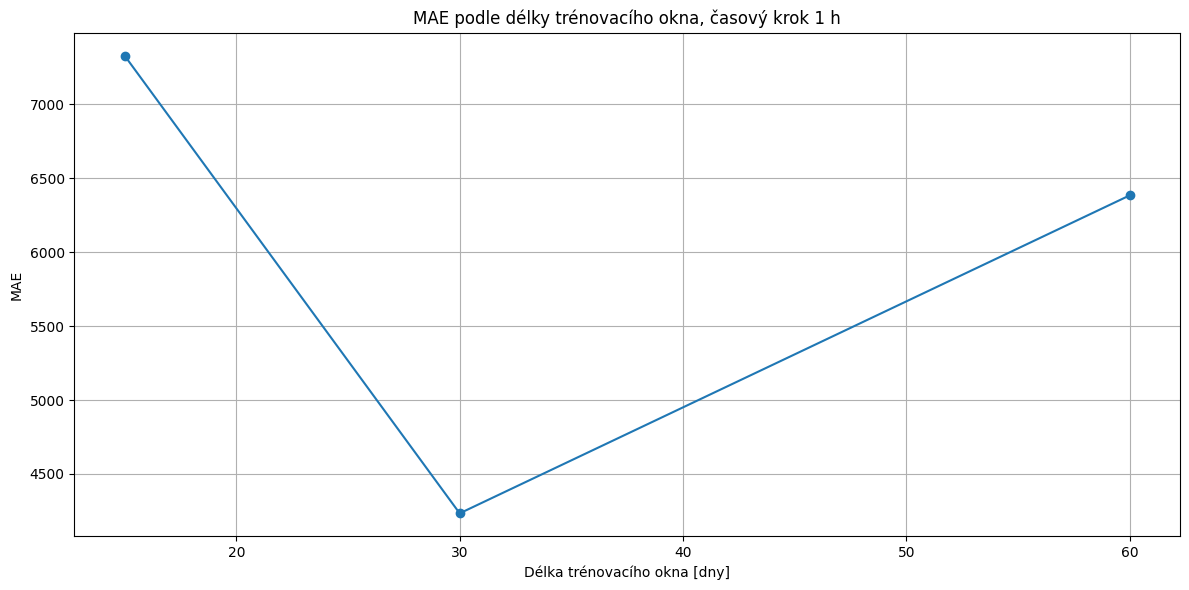

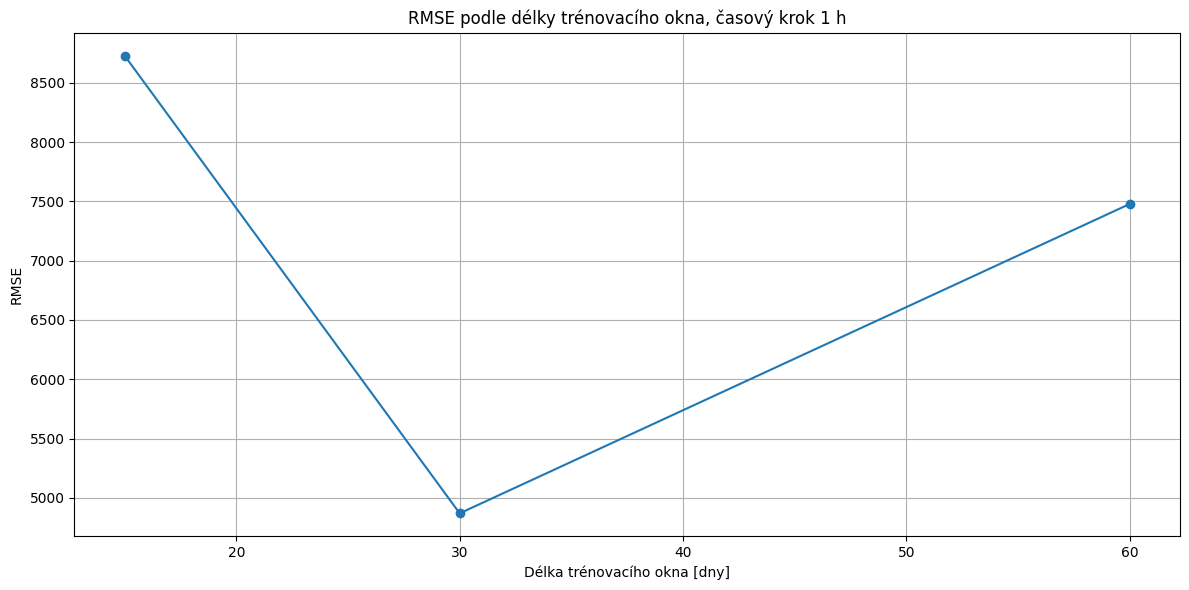

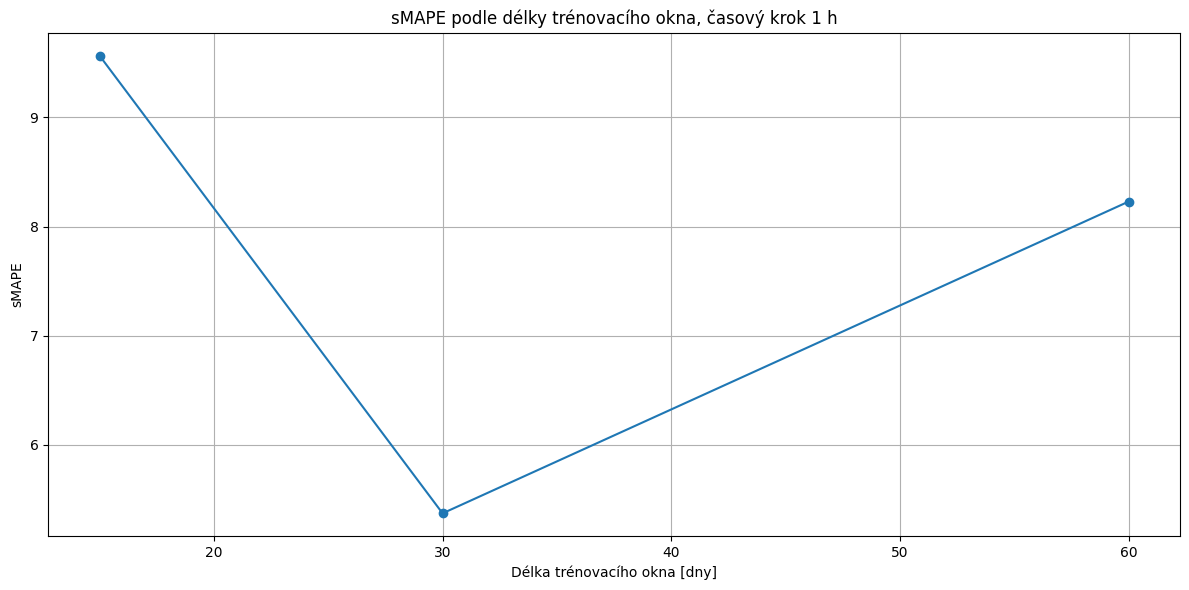

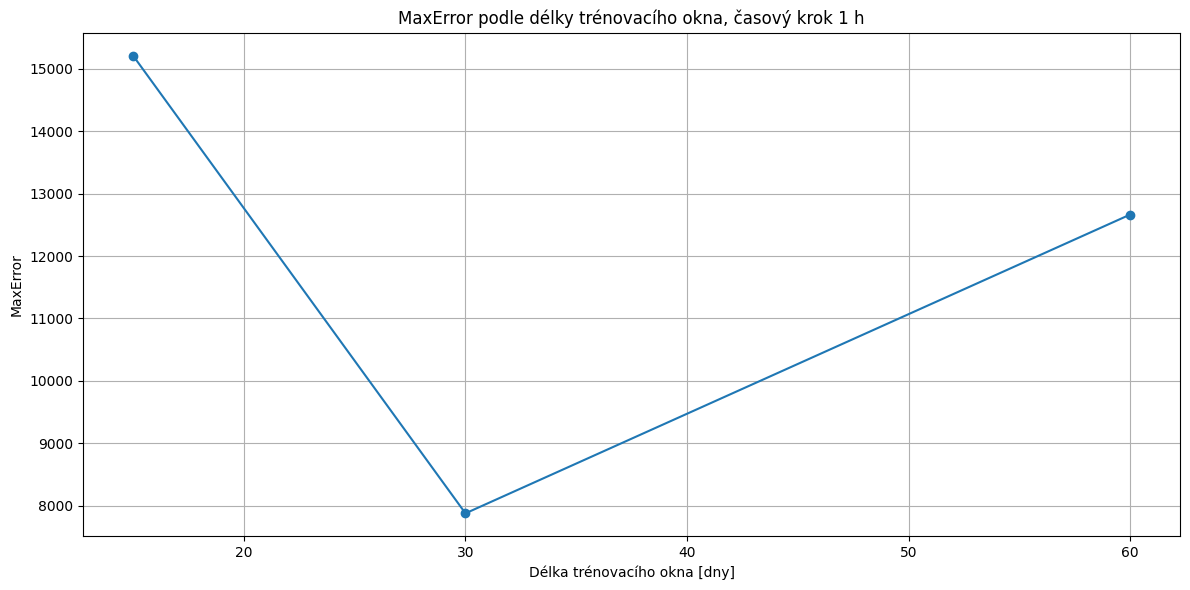

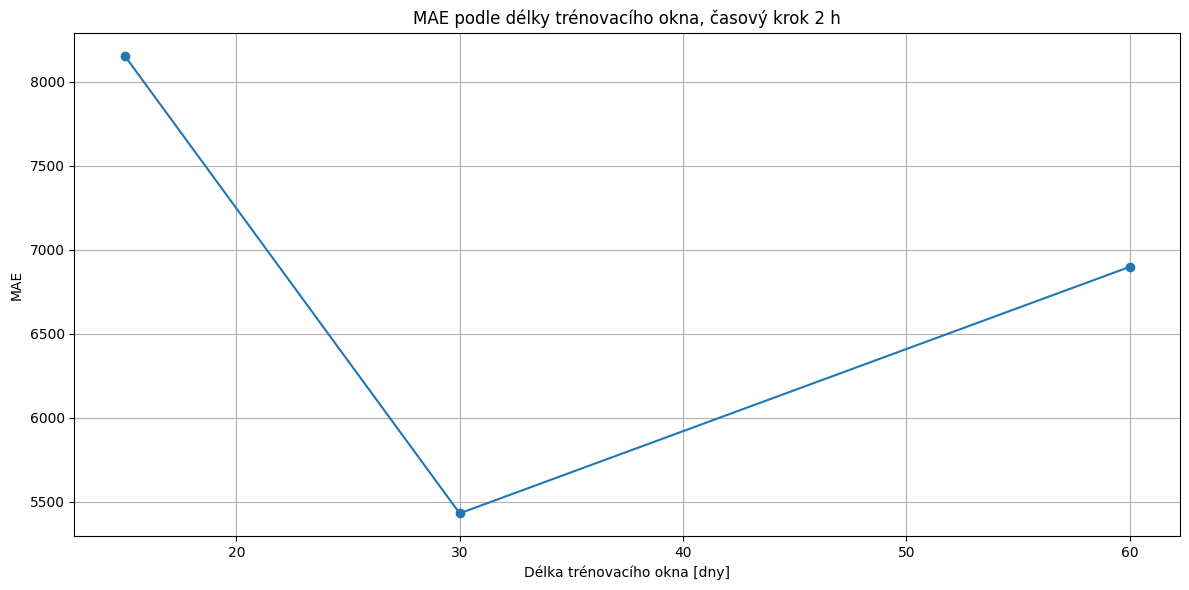

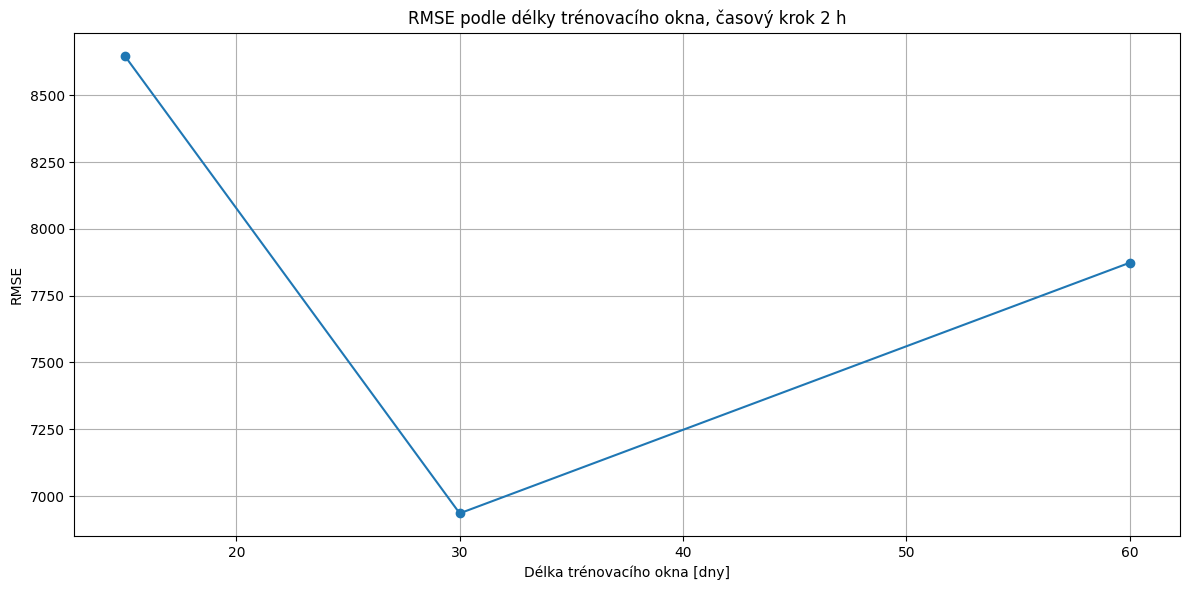

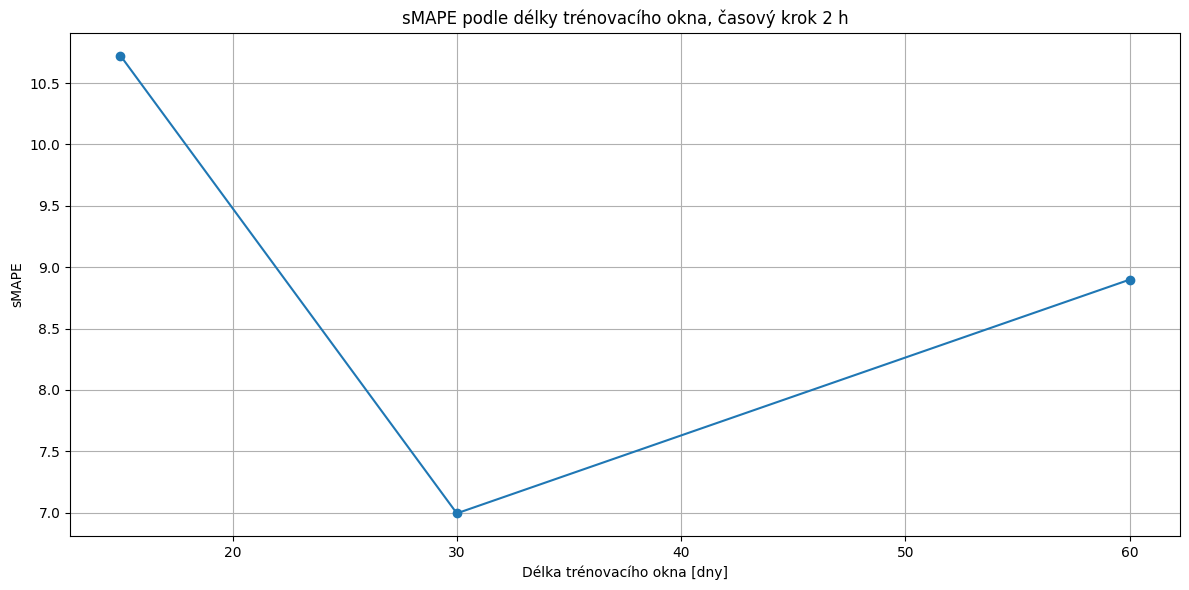

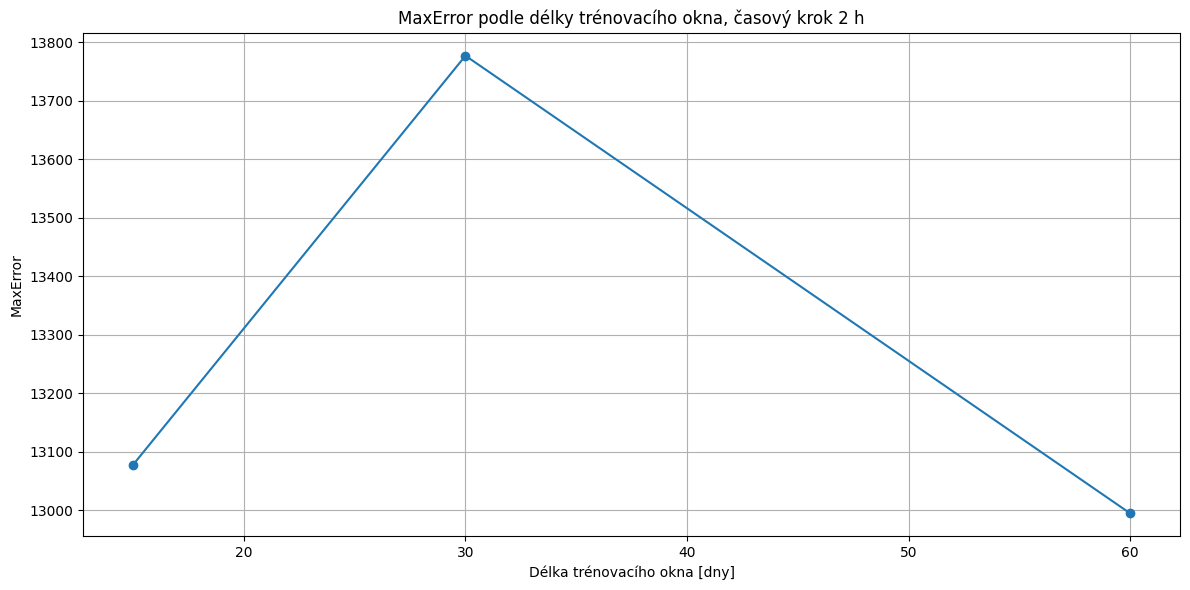

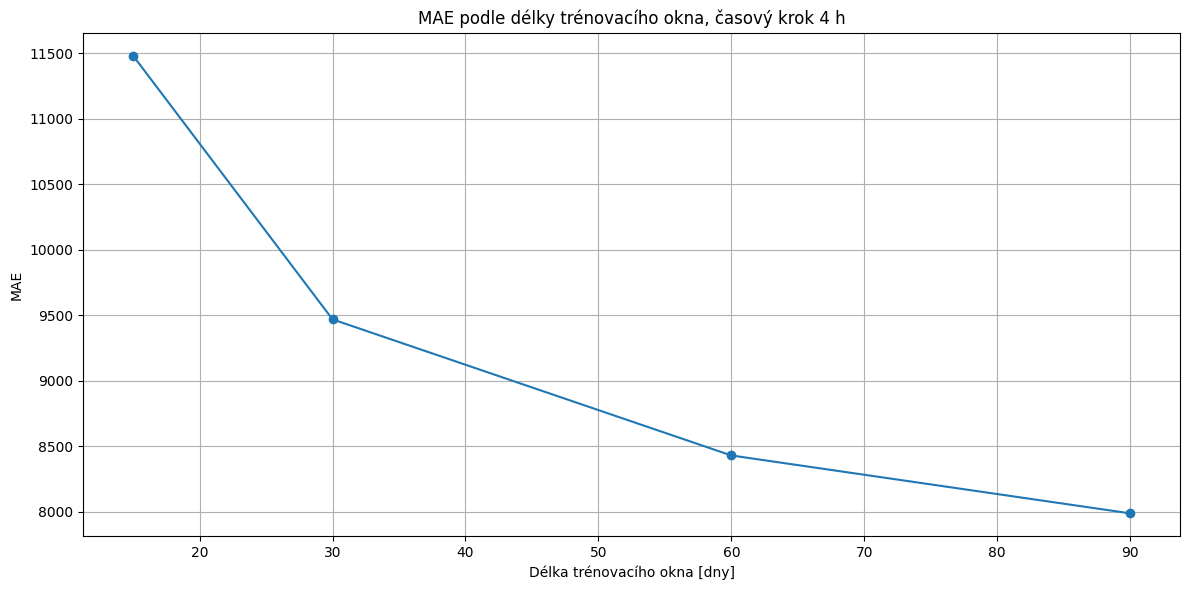

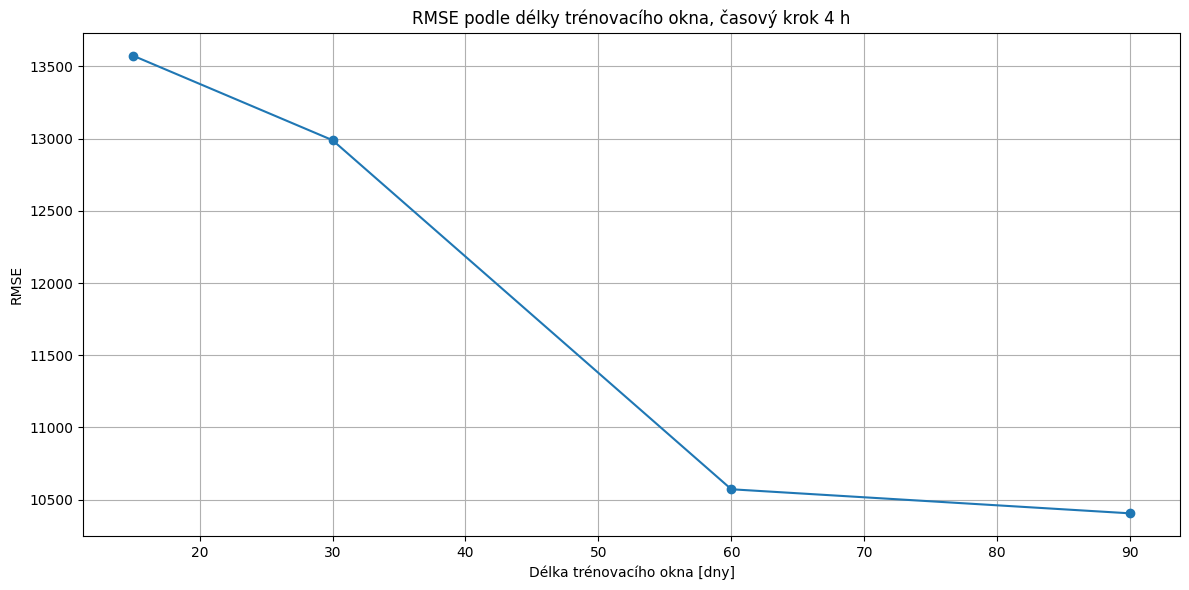

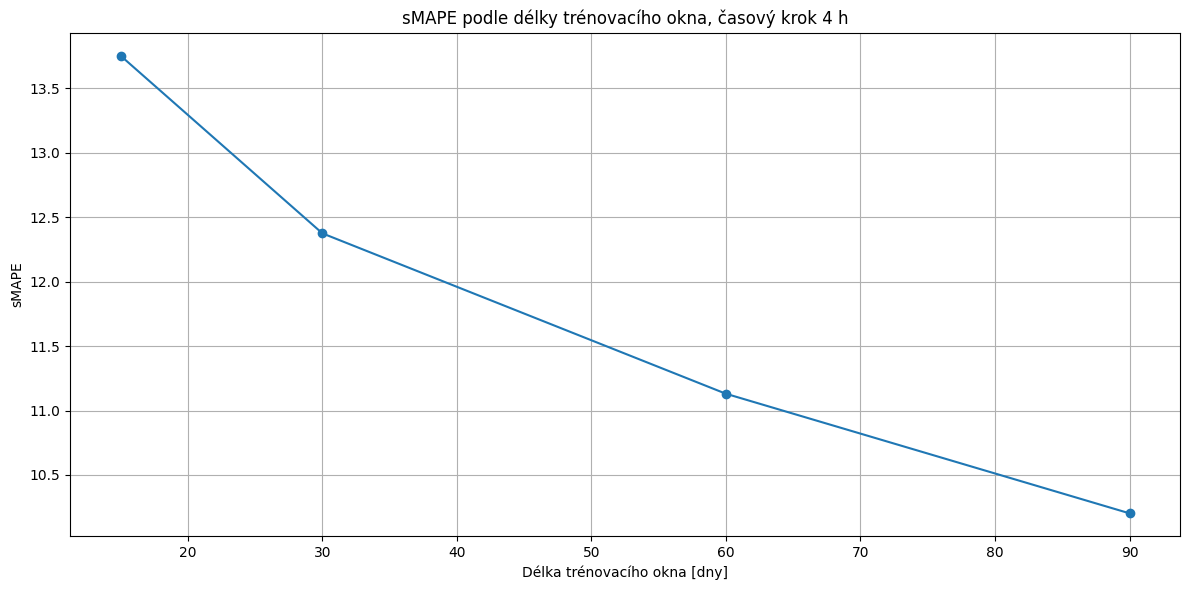

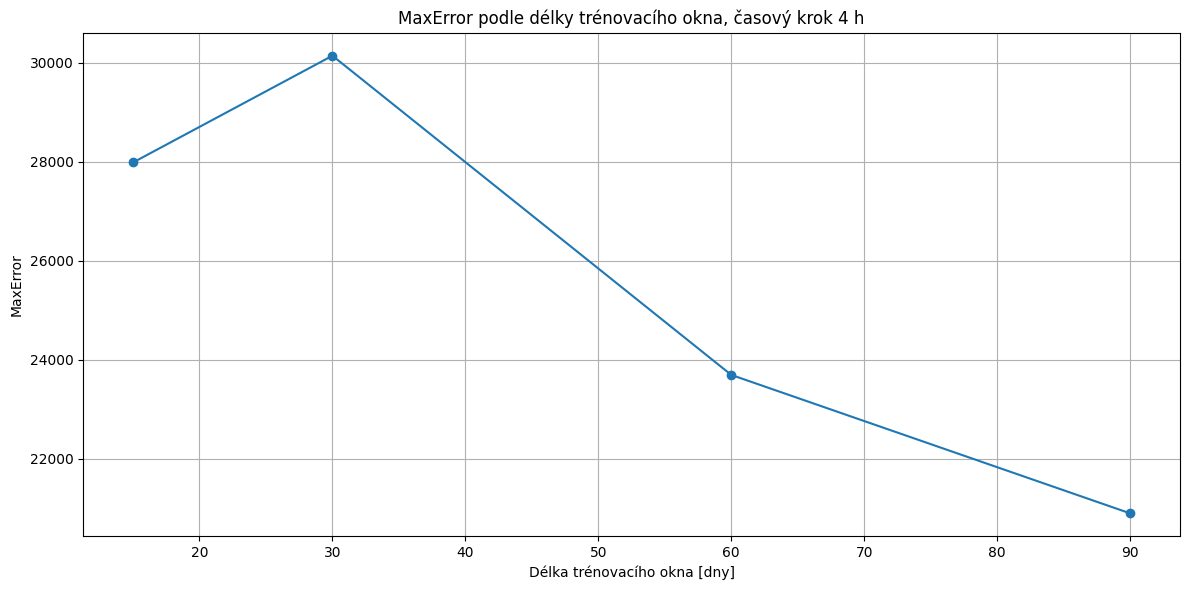

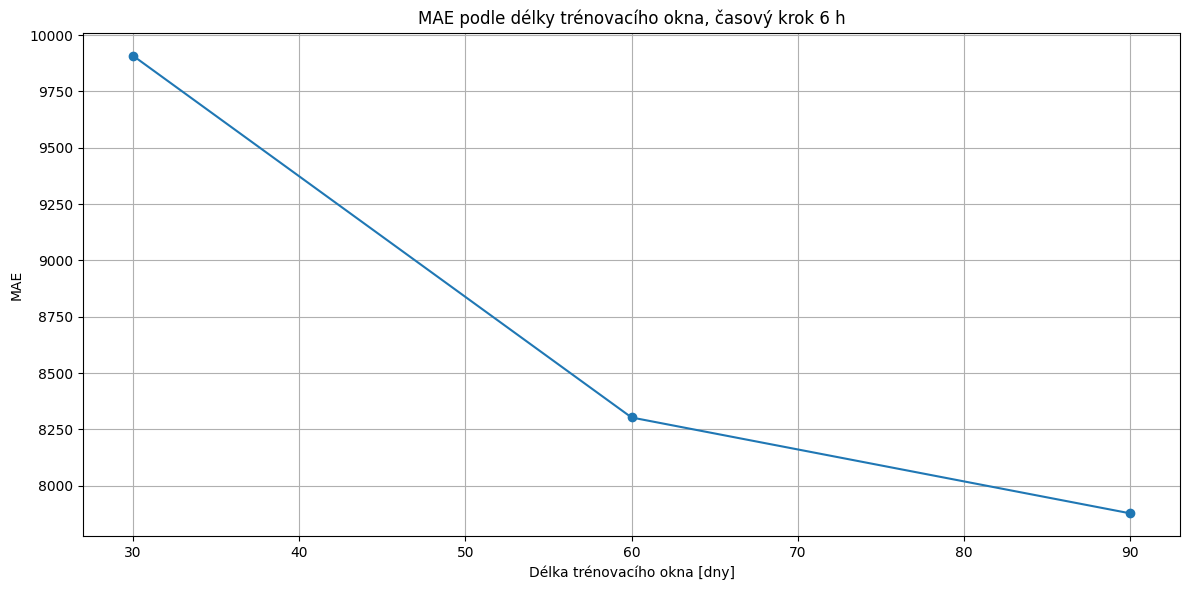

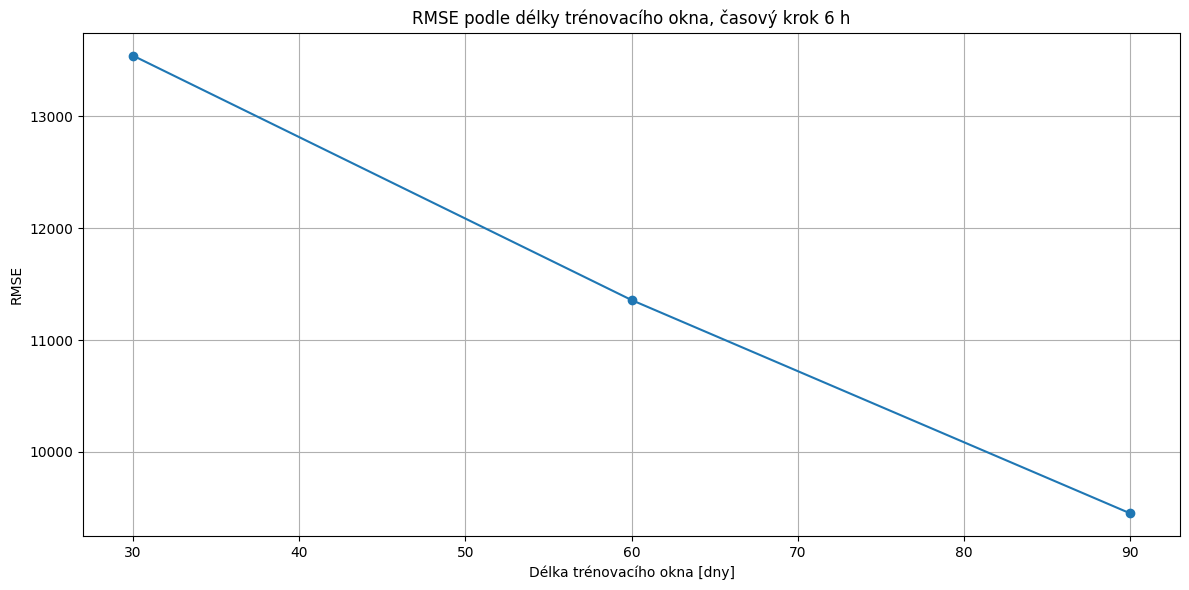

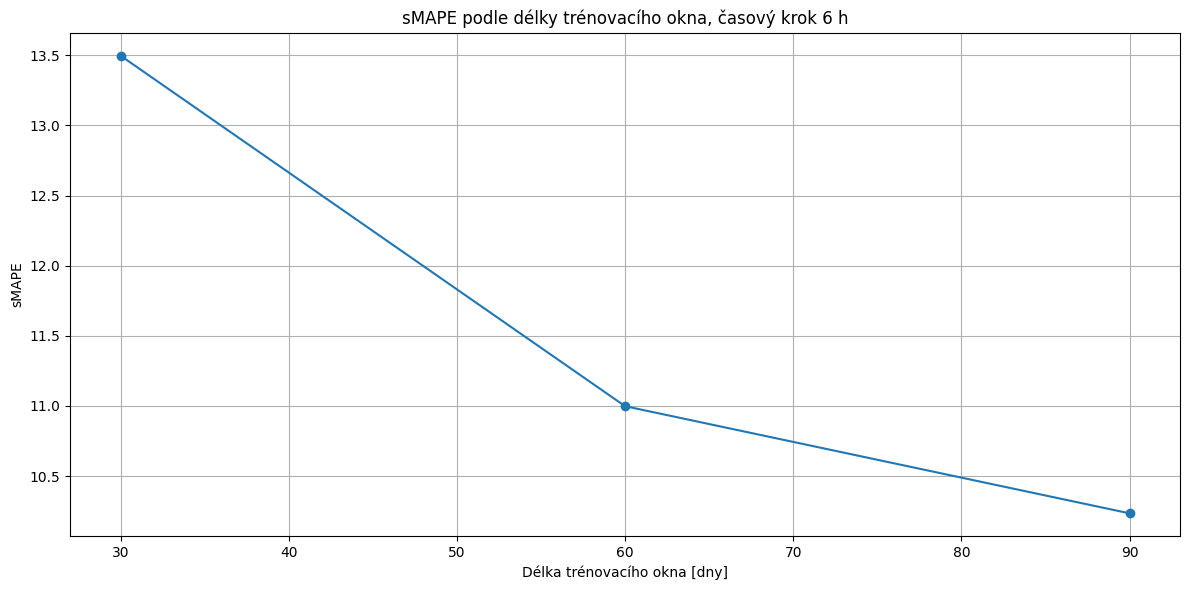

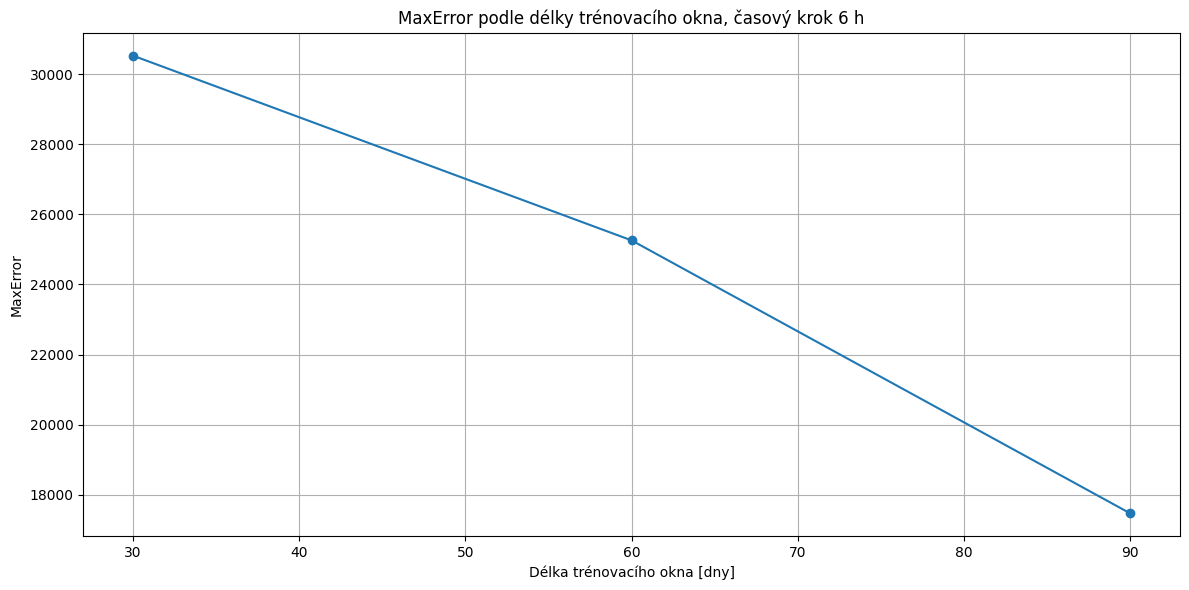

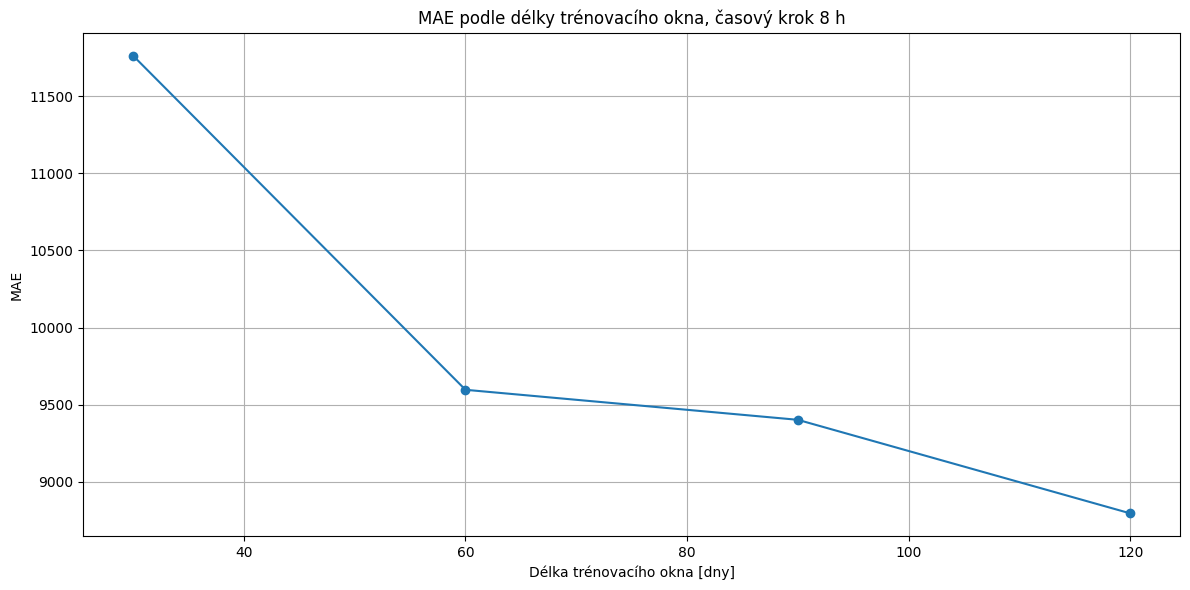

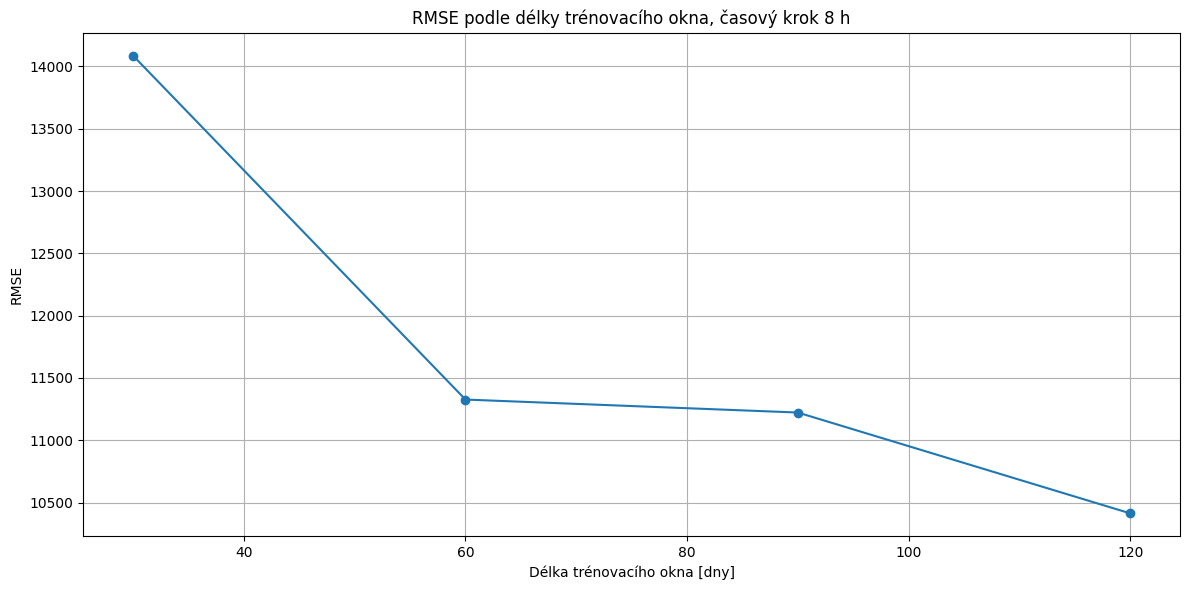

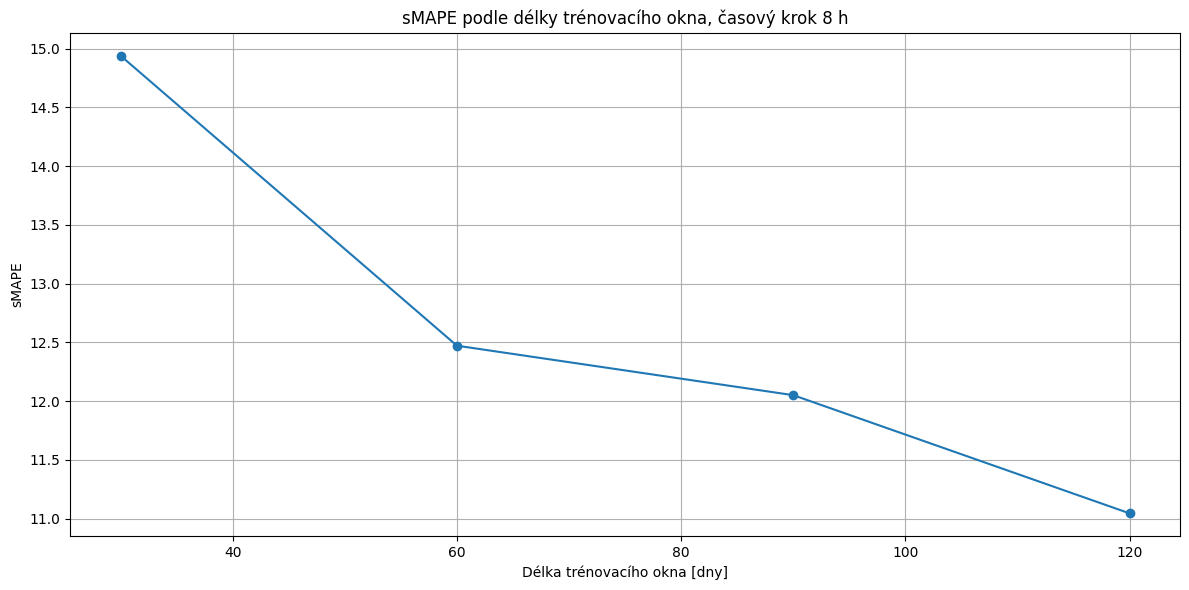

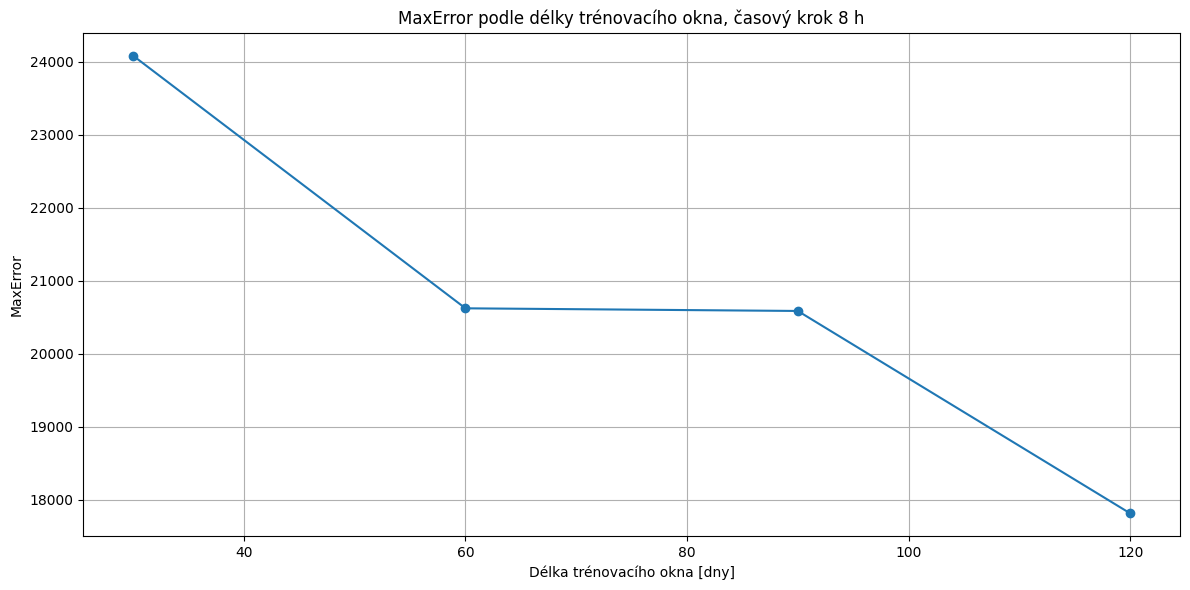

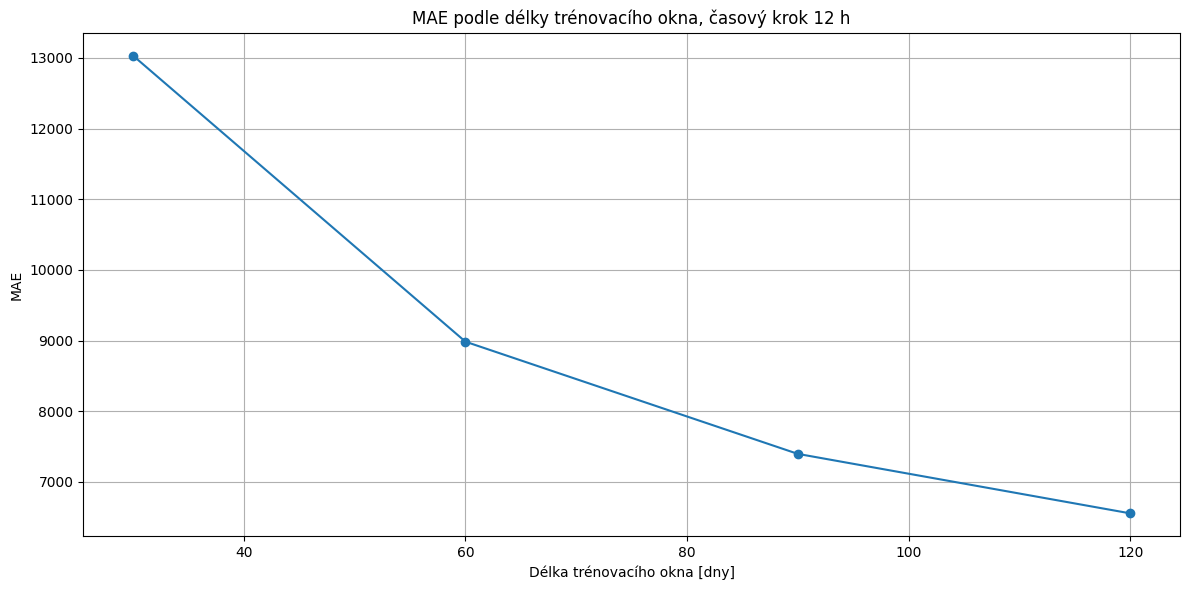

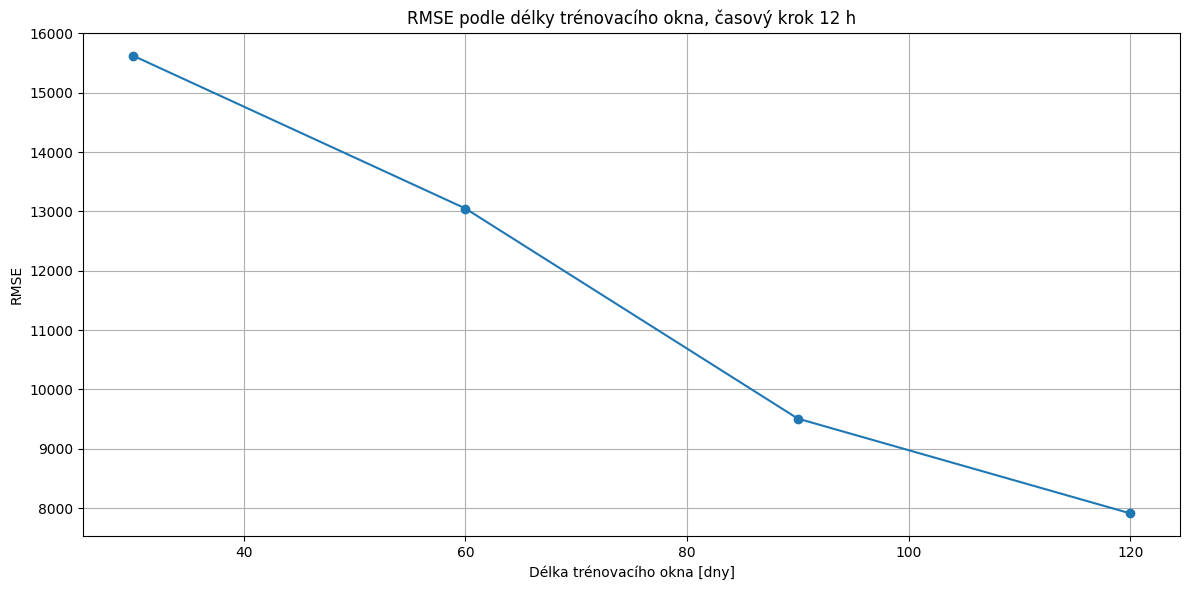

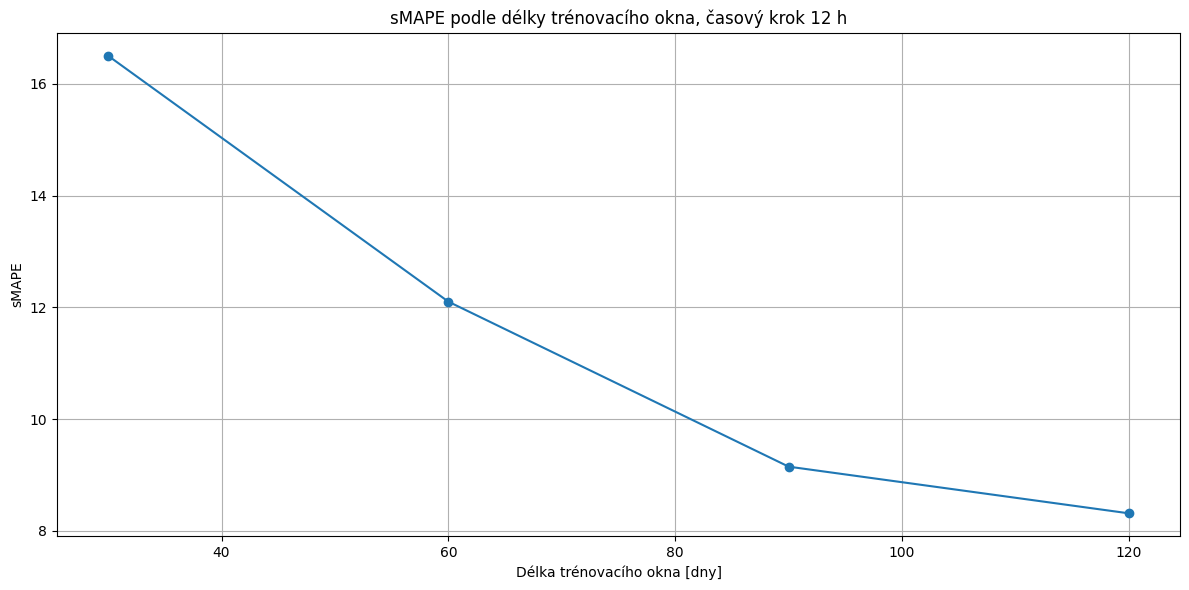

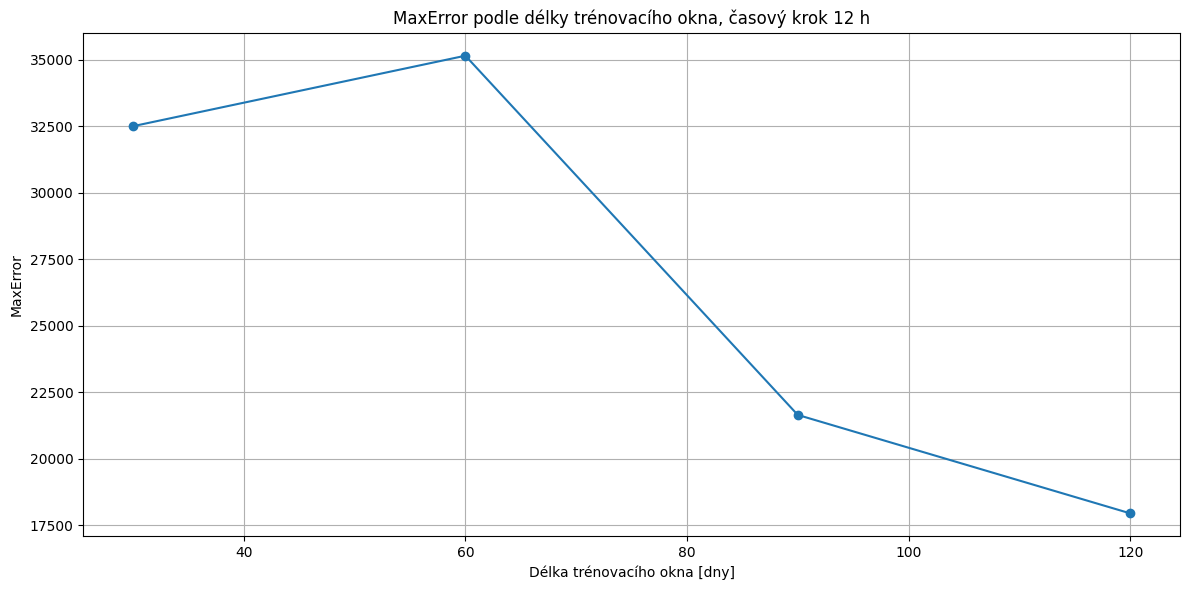

In [7]:
metrics = ["MAE", "RMSE", "sMAPE", "MaxError"]

for step in sorted(summary["step_hours"].unique()):
    step_summary = summary[summary["step_hours"] == step].copy()

    for metric in metrics:
        plt.figure()

        plt.plot(
            step_summary["train_days"],
            step_summary[metric],
            marker="o"
        )

        plt.title(f"{metric} podle délky trénovacího okna, časový krok {step} h")
        plt.xlabel("Délka trénovacího okna [dny]")
        plt.ylabel(metric)

        save_plot(f"{metric}_vs_training_days_{step}h.png")

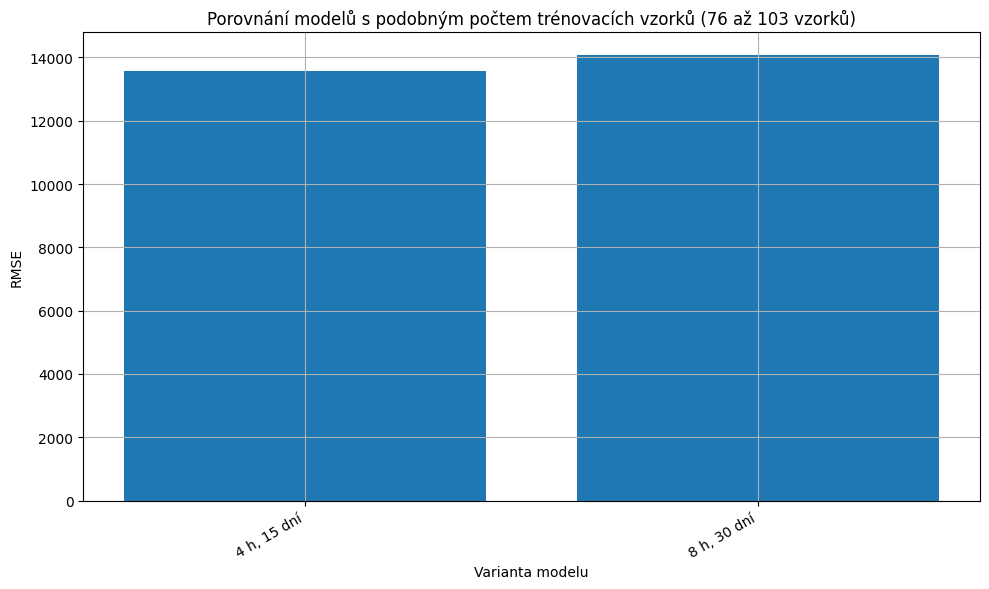

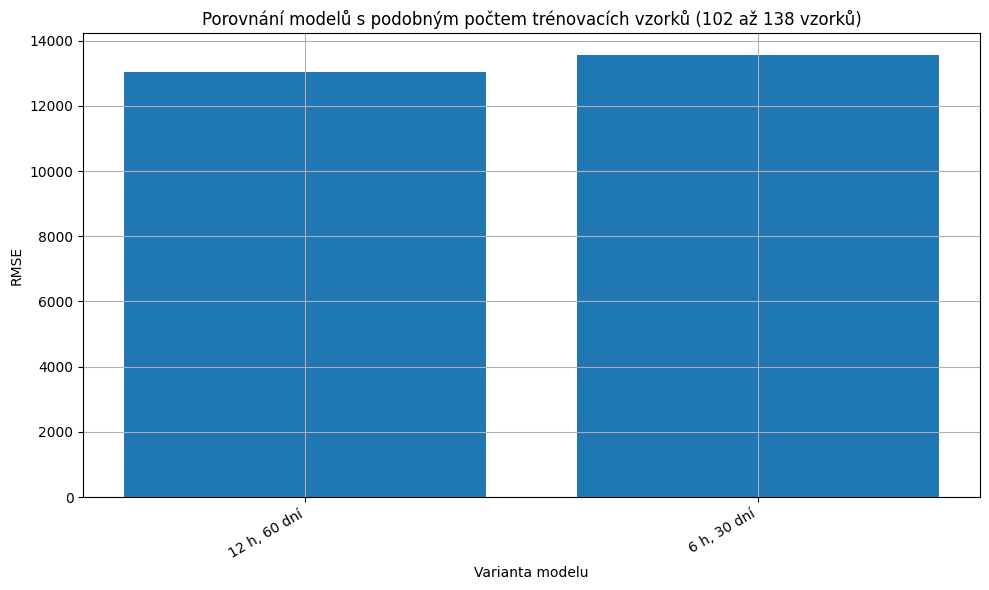

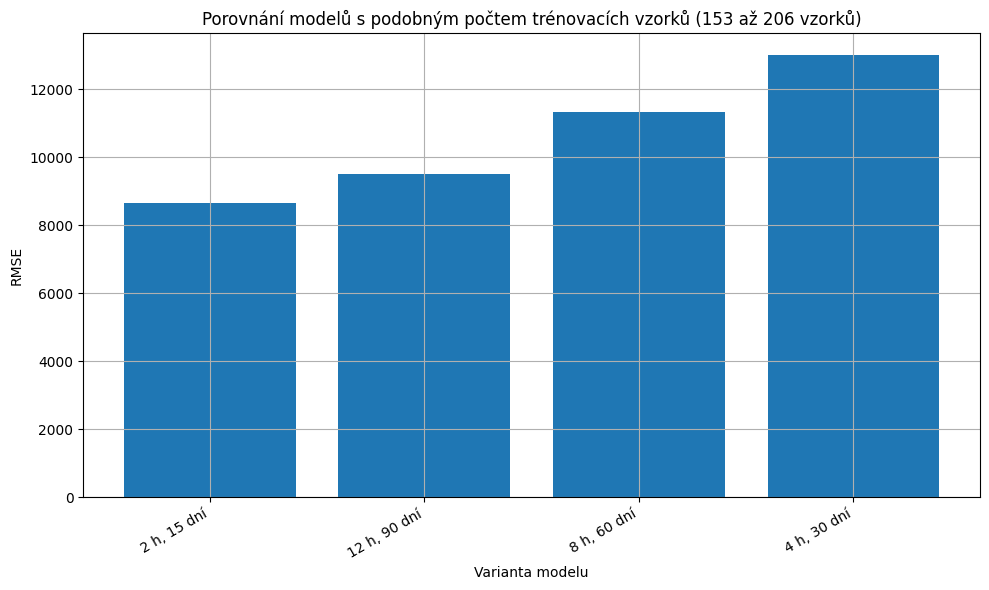

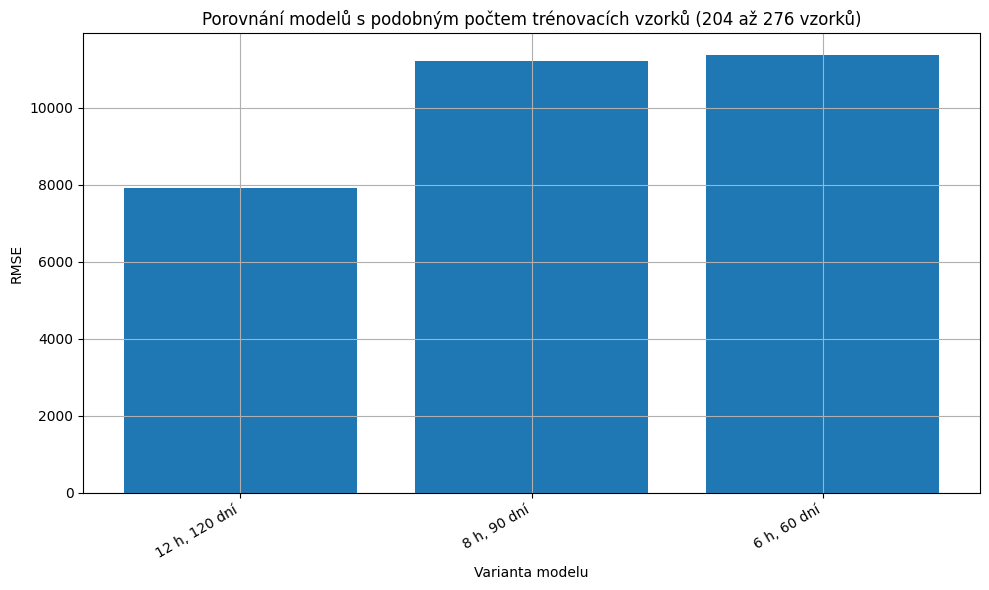

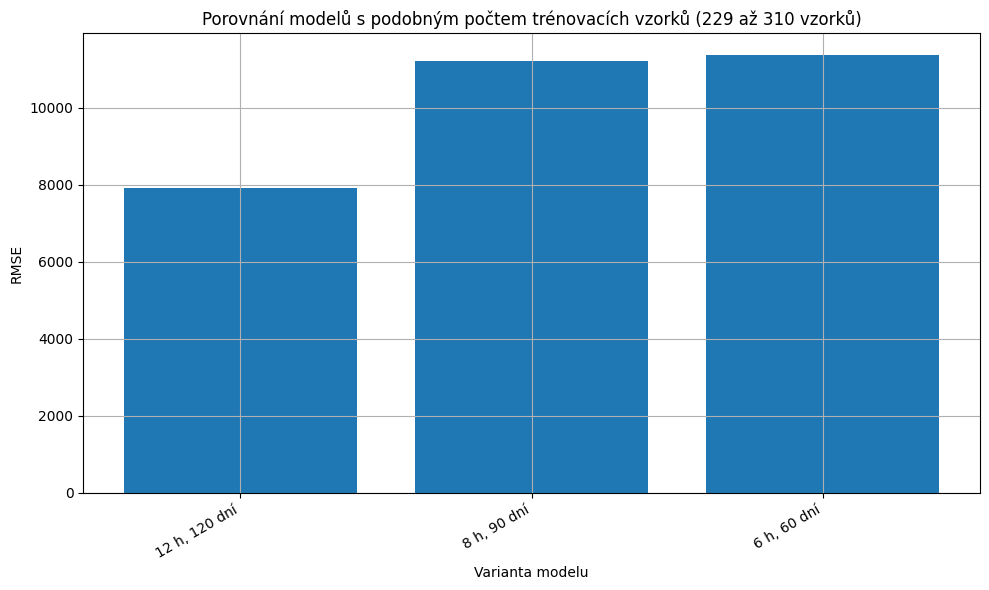

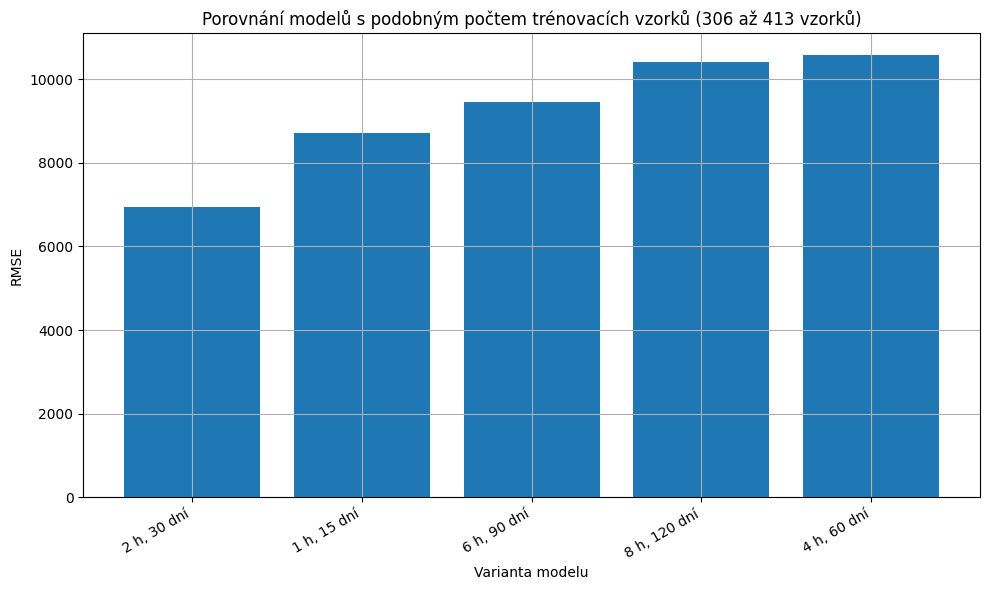

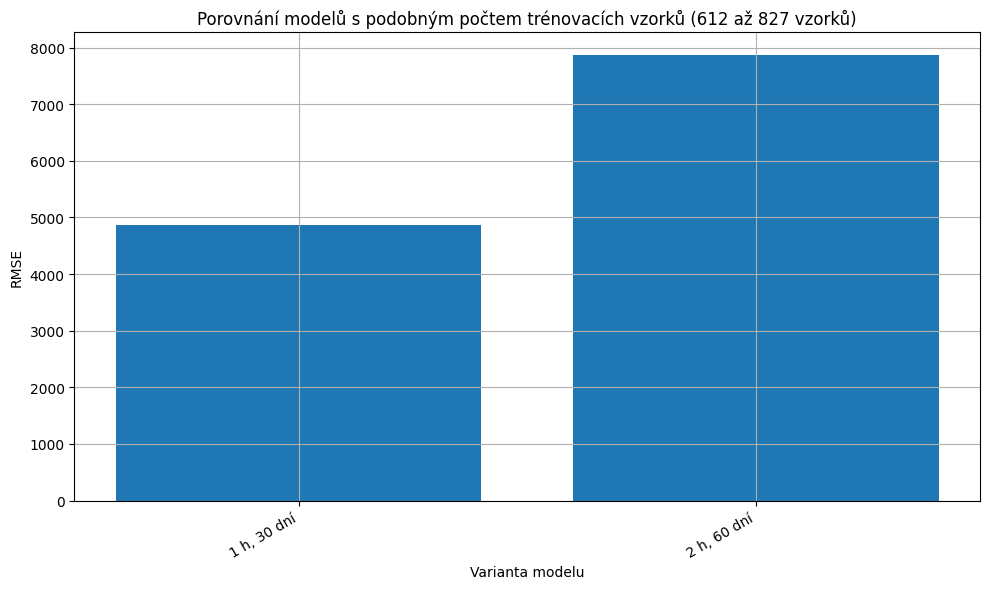

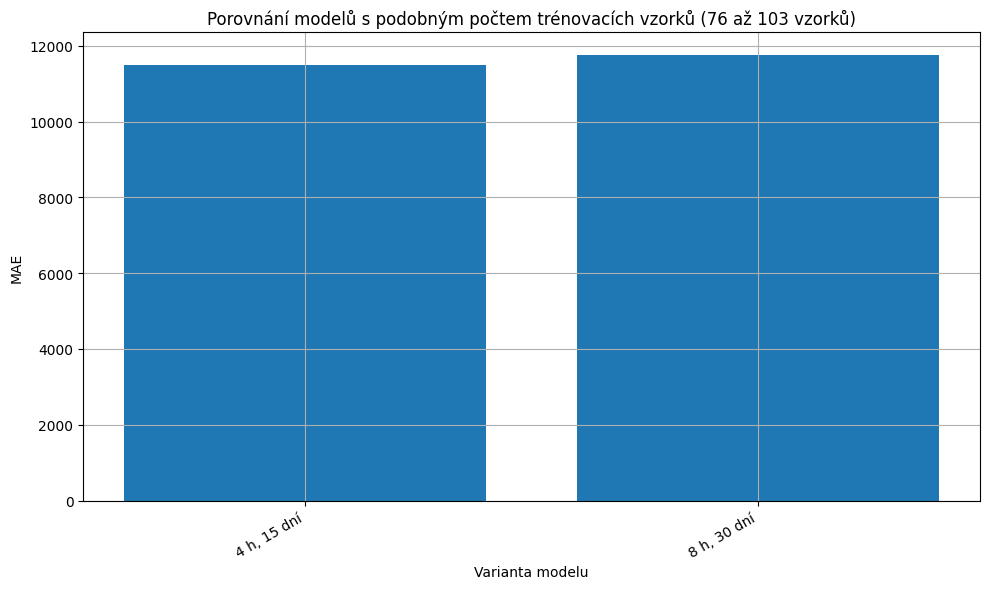

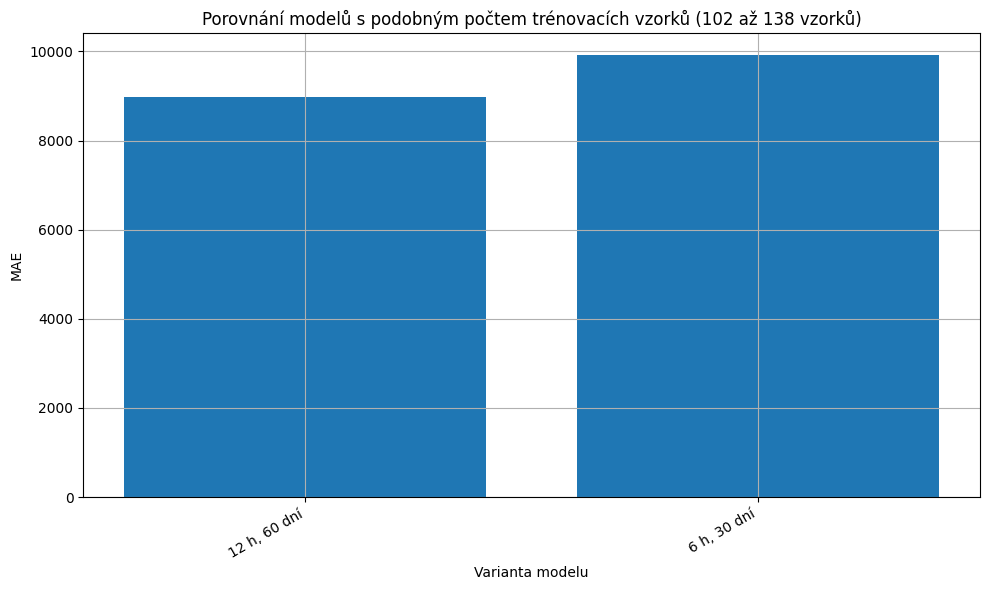

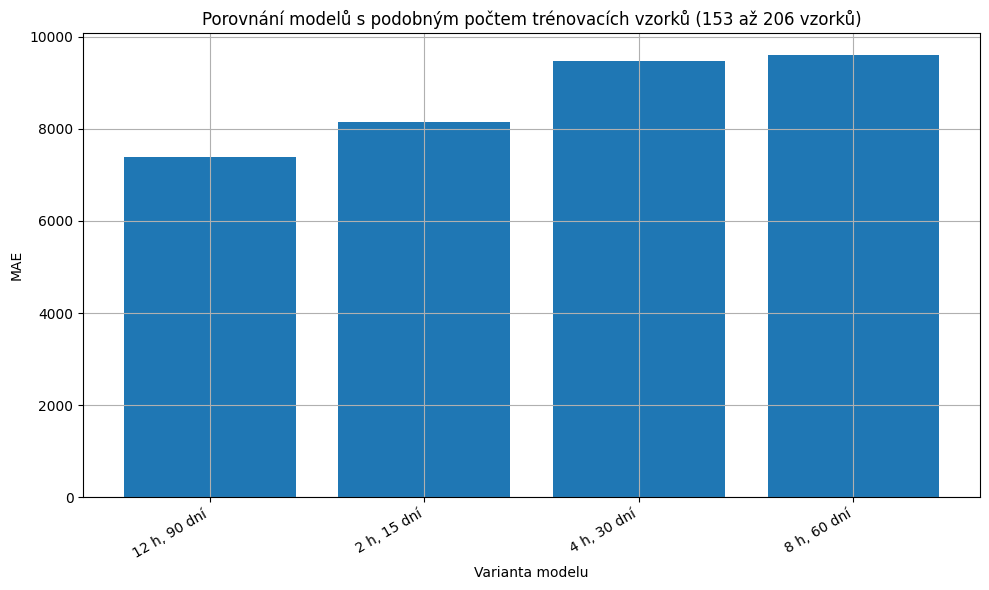

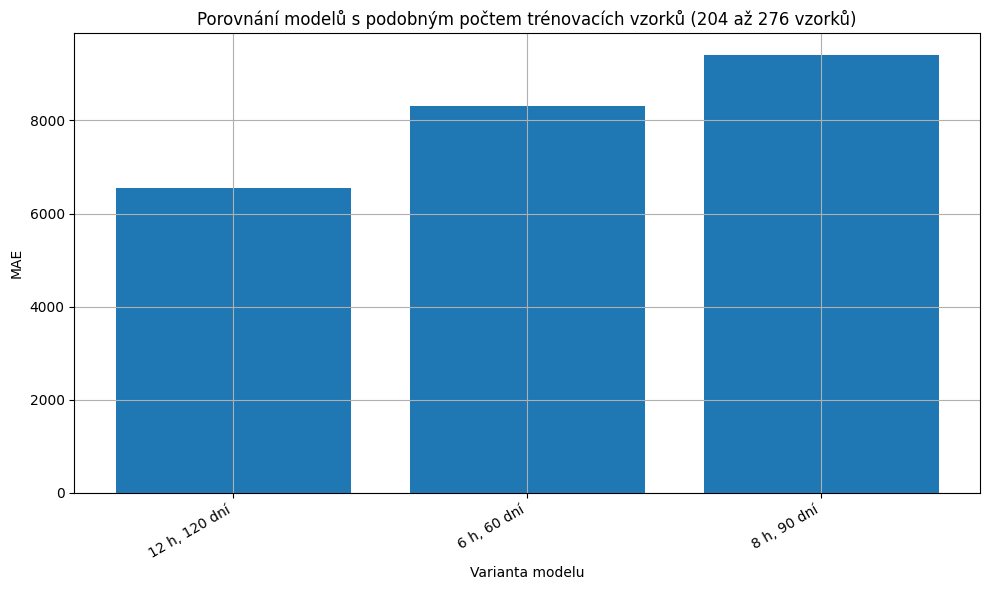

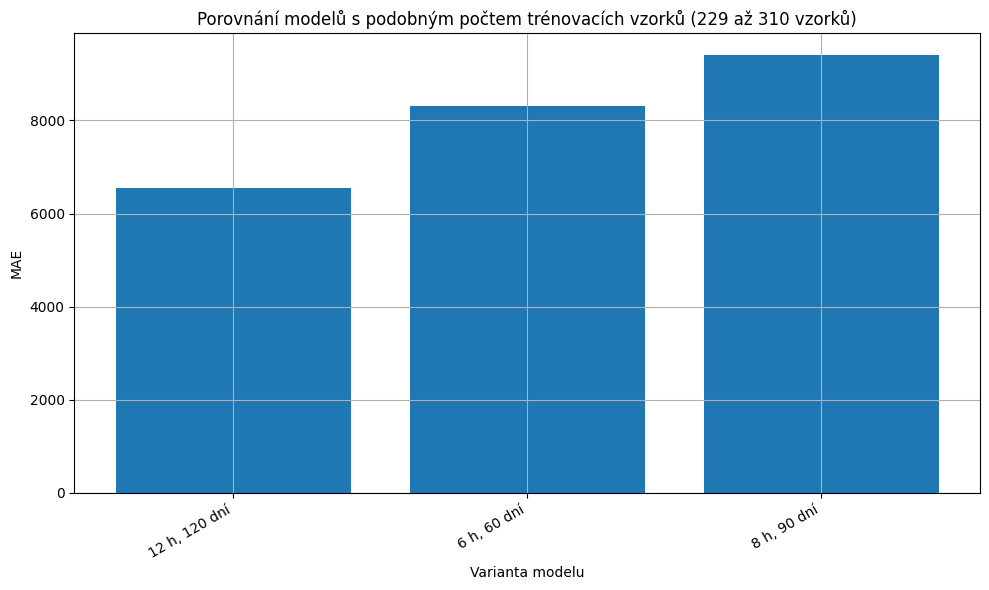

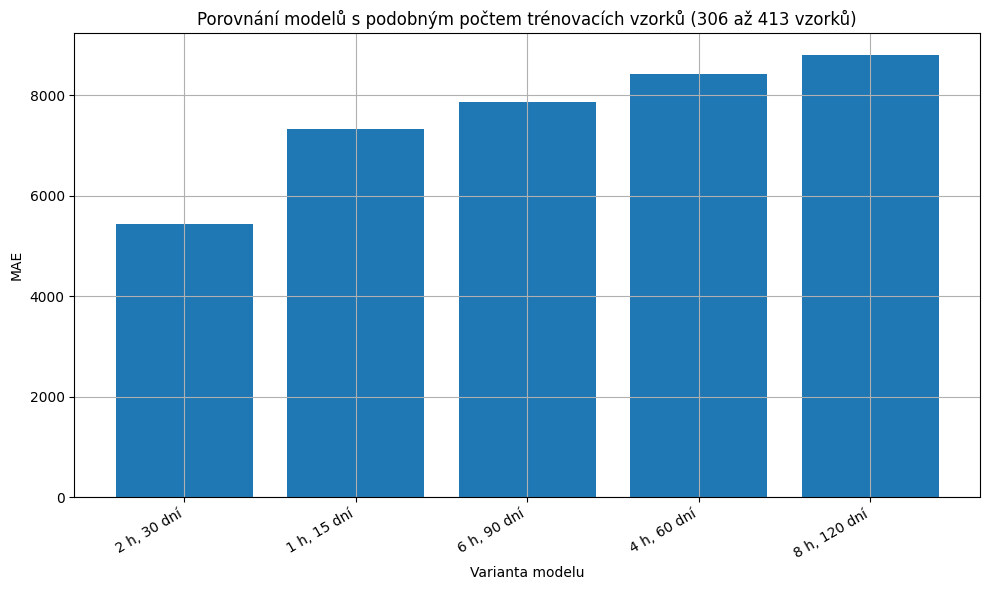

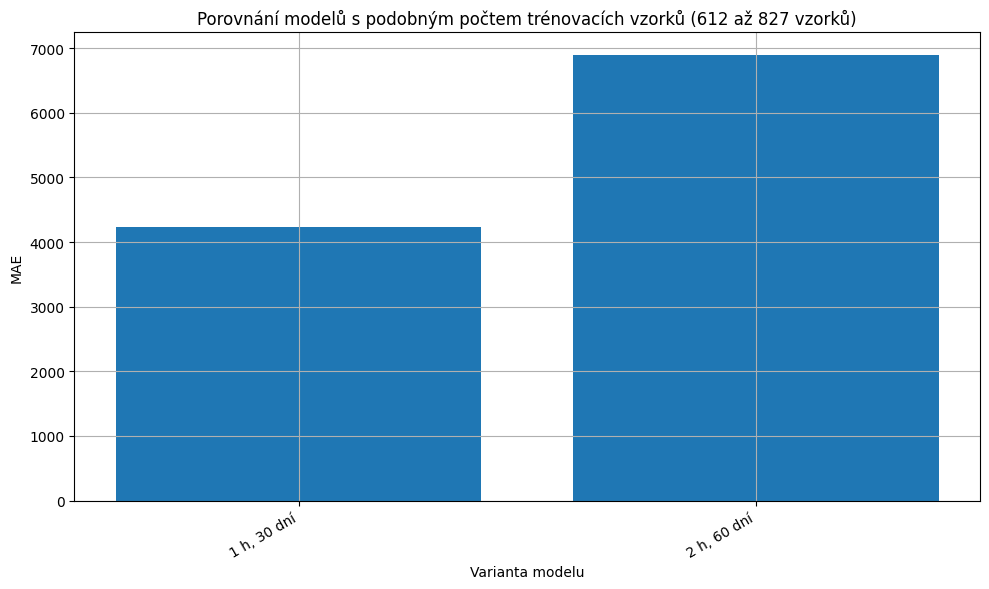

In [8]:
def plot_similar_train_samples(summary, metric="RMSE", tolerance=0.15):
    unique_samples = sorted(summary["train_samples"].unique())

    for base_samples in unique_samples:
        lower = base_samples * (1 - tolerance)
        upper = base_samples * (1 + tolerance)

        subset = summary[
            (summary["train_samples"] >= lower) &
            (summary["train_samples"] <= upper)
        ].copy()

        if subset["step_hours"].nunique() < 2:
            continue

        subset["label"] = (
            subset["step_hours"].astype(str) + " h, " +
            subset["train_days"].astype(str) + " dní"
        )

        subset = subset.sort_values(metric)

        plt.figure(figsize=(10, 6))

        plt.bar(subset["label"], subset[metric])

        plt.title(
            f"Porovnání modelů s podobným počtem trénovacích vzorků "
            f"({int(lower)} až {int(upper)} vzorků)"
        )
        plt.xlabel("Varianta modelu")
        plt.ylabel(metric)
        plt.xticks(rotation=30, ha="right")

        save_plot(f"similar_train_samples_{base_samples}_{metric}.png")


plot_similar_train_samples(summary, metric="RMSE")
plot_similar_train_samples(summary, metric="MAE")

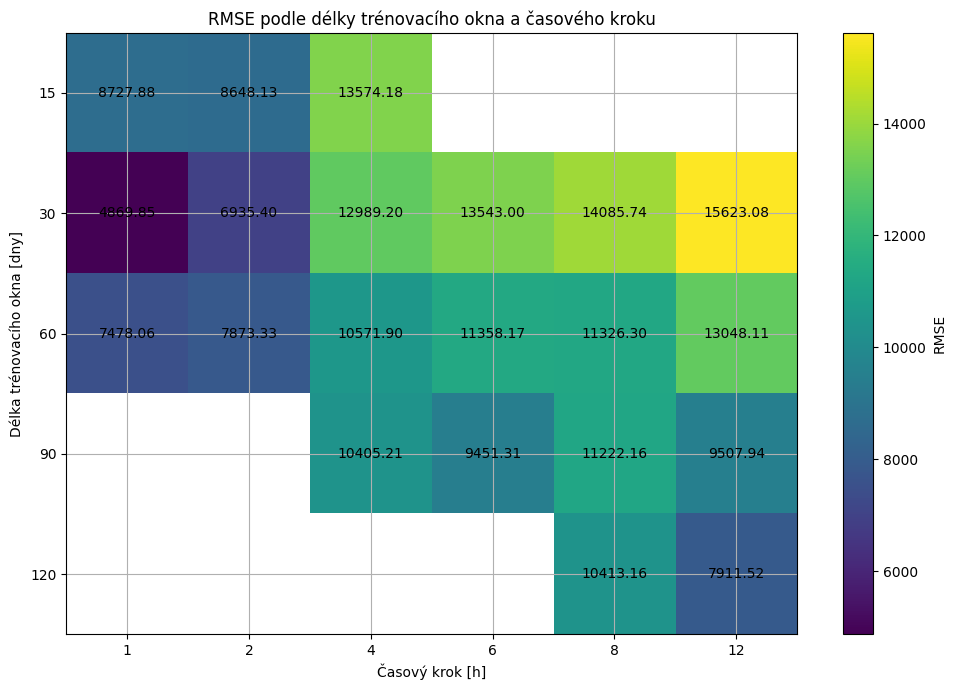

In [9]:
pivot = summary.pivot_table(
    values="RMSE",
    index="train_days",
    columns="step_hours",
    aggfunc="mean"
)

plt.figure(figsize=(10, 7))

plt.imshow(pivot, aspect="auto")
plt.colorbar(label="RMSE")

plt.xticks(
    ticks=np.arange(len(pivot.columns)),
    labels=pivot.columns
)

plt.yticks(
    ticks=np.arange(len(pivot.index)),
    labels=pivot.index
)

for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        value = pivot.iloc[i, j]
        if not np.isnan(value):
            plt.text(j, i, f"{value:.2f}", ha="center", va="center")

plt.title("RMSE podle délky trénovacího okna a časového kroku")
plt.xlabel("Časový krok [h]")
plt.ylabel("Délka trénovacího okna [dny]")

save_plot("rmse_heatmap_train_days_step_hours.png")

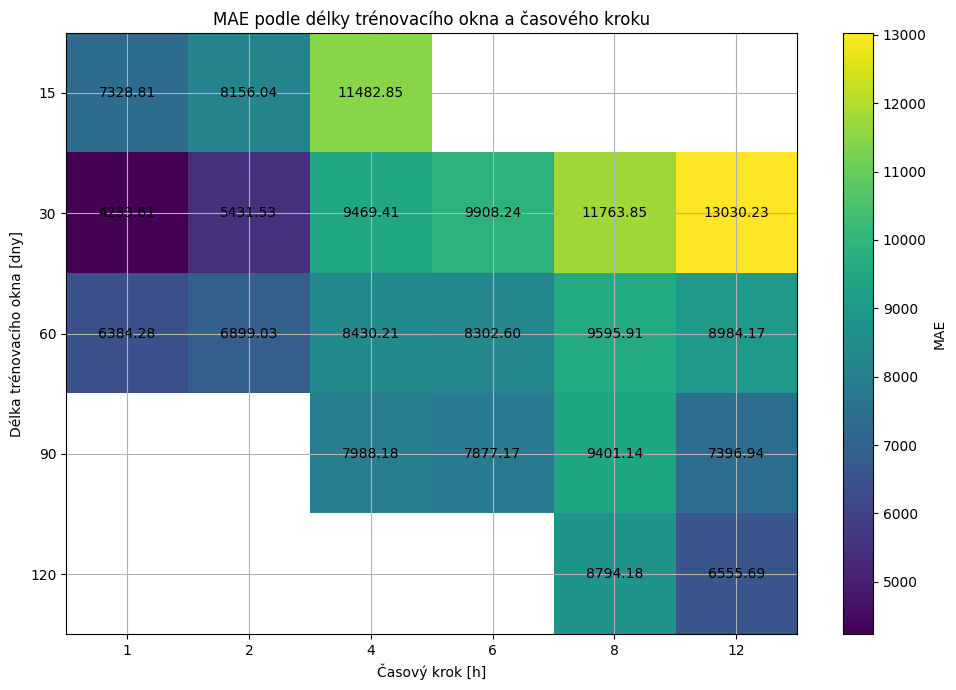

In [10]:
pivot = summary.pivot_table(
    values="MAE",
    index="train_days",
    columns="step_hours",
    aggfunc="mean"
)

plt.figure(figsize=(10, 7))

plt.imshow(pivot, aspect="auto")
plt.colorbar(label="MAE")

plt.xticks(
    ticks=np.arange(len(pivot.columns)),
    labels=pivot.columns
)

plt.yticks(
    ticks=np.arange(len(pivot.index)),
    labels=pivot.index
)

for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        value = pivot.iloc[i, j]
        if not np.isnan(value):
            plt.text(j, i, f"{value:.2f}", ha="center", va="center")

plt.title("MAE podle délky trénovacího okna a časového kroku")
plt.xlabel("Časový krok [h]")
plt.ylabel("Délka trénovacího okna [dny]")

save_plot("mae_heatmap_train_days_step_hours.png")

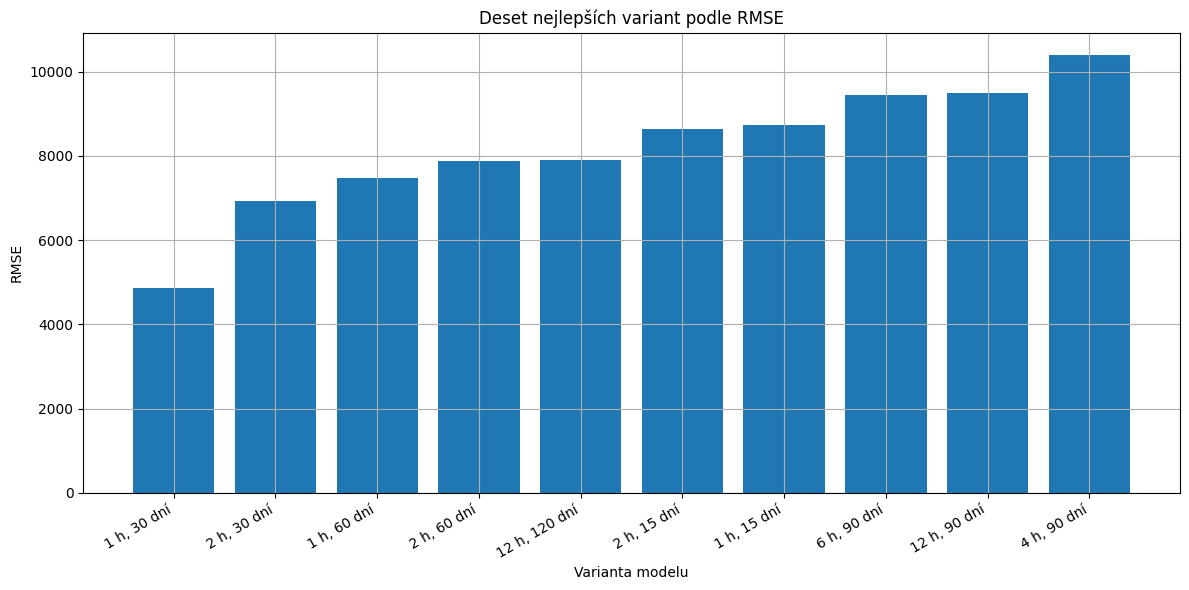

,step_hours,train_days,train_samples,MAE,MSE,RMSE,sMAPE,MeanError,MaxError,label
1,1,30,720,4233.606454,2.371539e+07,4869.845185,5.371650,433.630964,7876.131160,"1 h, 30 dní"
4,2,30,360,5431.529730,4.809980e+07,6935.402008,6.995184,3986.144107,13776.902267,"2 h, 30 dní"
2,1,60,1440,6384.278070,5.592137e+07,7478.059099,8.228693,3003.763609,12664.083405,"1 h, 60 dní"
5,2,60,720,6899.034048,6.198938e+07,7873.333787,8.898674,3294.929250,12994.630826,"2 h, 60 dní"
20,12,120,240,6555.686676,6.259217e+07,7911.521179,8.315237,1928.502616,17947.284697,"12 h, 120 dní"
3,2,15,180,8156.042706,7.479011e+07,8648.127312,10.723191,1606.401298,13077.763229,"2 h, 15 dní"
0,1,15,360,7328.814316,7.617586e+07,8727.878276,9.565855,908.152142,15209.794068,"1 h, 15 dní"
12,6,90,360,7877.165744,8.932718e+07,9451.305808,10.234531,4473.208382,17472.770248,"6 h, 90 dní"
19,12,90,180,7396.943409,9.040090e+07,9507.938716,9.150838,-513.061683,21646.251588,"12 h, 90 dní"
9,4,90,540,7988.184715,1.082683e+08,10405.206191,10.202589,3764.689475,20901.240181,"4 h, 90 dní"


In [11]:
best_models = summary.sort_values("RMSE").head(10).copy()

best_models["label"] = (
    best_models["step_hours"].astype(str) + " h, " +
    best_models["train_days"].astype(str) + " dní"
)

plt.figure(figsize=(12, 6))

plt.bar(best_models["label"], best_models["RMSE"])

plt.title("Deset nejlepších variant podle RMSE")
plt.xlabel("Varianta modelu")
plt.ylabel("RMSE")
plt.xticks(rotation=30, ha="right")

save_plot("top_10_models_by_rmse.png")

display(best_models)

Sloupce: ['date', 'forecast', 'actual', 'weather_combo']


,date,forecast,actual,weather_combo
0,2026-01-20 00:00:00,3382.402953,3324.11425,[]
1,2026-01-20 01:00:00,3291.438983,3196.69175,[]
2,2026-01-20 02:00:00,3109.424935,3564.13325,[]
3,2026-01-20 03:00:00,2973.756508,2707.38300,[]
4,2026-01-20 04:00:00,3367.881018,2789.41325,[]


,weather_combo,RMSE,MAE
4,"['pressure', 'temperature']",883.210967,668.362409
2,"['pressure', 'precipitation', 'temperature']",884.090934,669.534314
13,"['wind_speed', 'temperature']",884.428965,666.790687
3,"['pressure', 'precipitation']",885.186832,671.953613
9,"['wind_speed', 'pressure', 'precipitation', 't...",885.572710,670.847847
5,['pressure'],885.683688,673.395687
7,"['wind_speed', 'precipitation', 'temperature']",885.949879,666.687914
15,[],886.341309,673.770587
11,"['wind_speed', 'pressure', 'temperature']",886.500049,673.030975
0,"['precipitation', 'temperature']",887.467391,671.244972


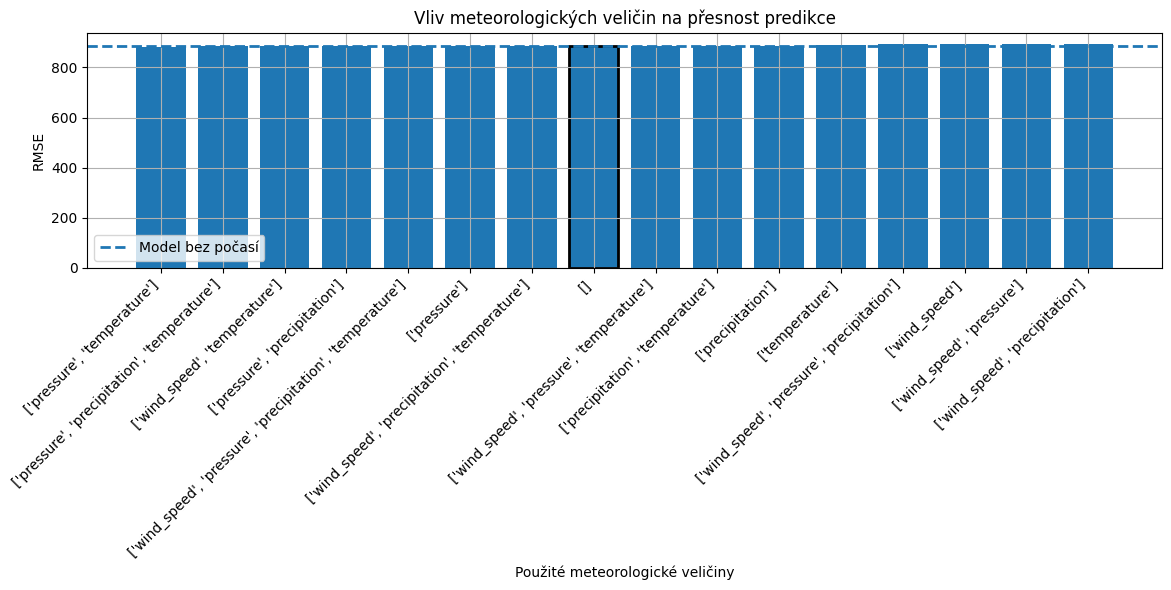

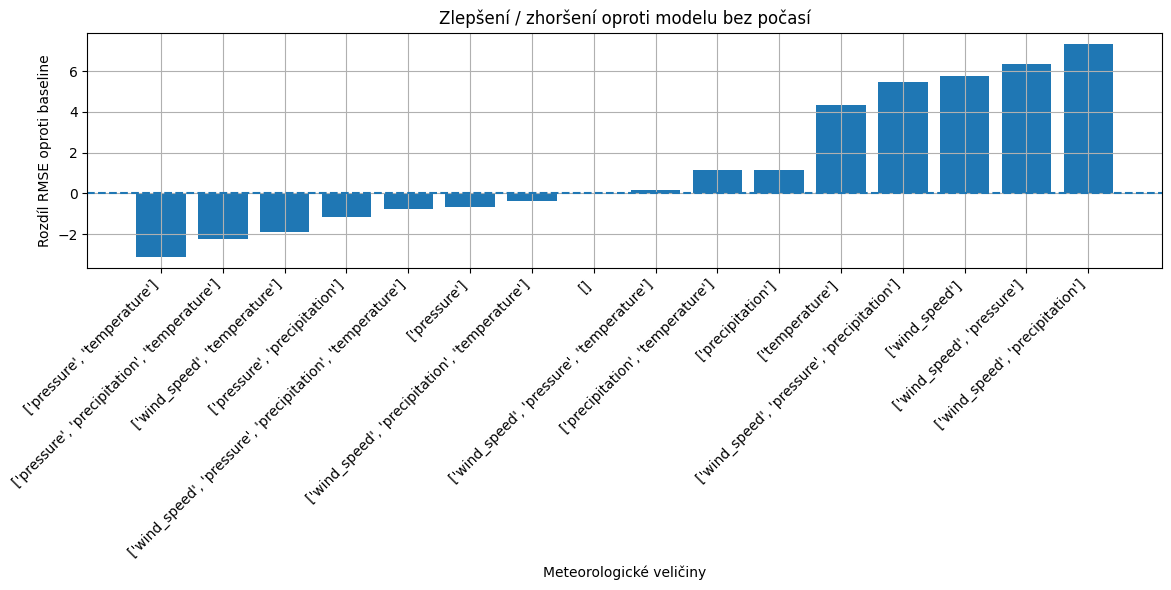

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================
# 1. Načtení dat
# ============================

file_path = "wheater_all_forecasts_allow_no_temp_30d.csv"

df = pd.read_csv(file_path, sep=";")

# kontrola
print("Sloupce:", df.columns.tolist())
display(df.head())

# ============================
# 2. Výpočet metrik
# ============================

df["error"] = df["actual"] - df["forecast"]
df["abs_error"] = np.abs(df["error"])
df["squared_error"] = df["error"]**2

summary = (
    df.groupby("weather_combo")
    .agg(
        RMSE=("squared_error", lambda x: np.sqrt(np.mean(x))),
        MAE=("abs_error", "mean")
    )
    .reset_index()
)

# baseline (bez počasí)
baseline_row = summary[summary["weather_combo"] == "[]"]

if baseline_row.empty:
    print("⚠️ Nebyla nalezena varianta bez počasí ([]).")
    baseline = None
else:
    baseline = baseline_row["RMSE"].values[0]

# seřazení
summary = summary.sort_values("RMSE")

display(summary)

# ============================
# 3. Graf RMSE
# ============================

plt.figure(figsize=(12,6))

bars = plt.bar(summary["weather_combo"], summary["RMSE"])

# zvýraznění baseline
if baseline is not None:
    for i, combo in enumerate(summary["weather_combo"]):
        if combo == "[]":
            bars[i].set_edgecolor("black")
            bars[i].set_linewidth(2)

    plt.axhline(
        baseline,
        linestyle="--",
        linewidth=2,
        label="Model bez počasí"
    )

plt.xticks(rotation=45, ha="right")

plt.xlabel("Použité meteorologické veličiny")
plt.ylabel("RMSE")
plt.title("Vliv meteorologických veličin na přesnost predikce")

if baseline is not None:
    plt.legend()

plt.tight_layout()
plt.savefig("weather_rmse_comparison.png", dpi=300)
plt.show()

# ============================
# 4. BONUS: rozdíl od baseline
# ============================

if baseline is not None:
    summary["delta_RMSE"] = summary["RMSE"] - baseline

    plt.figure(figsize=(12,6))

    plt.bar(summary["weather_combo"], summary["delta_RMSE"])
    plt.axhline(0, linestyle="--")

    plt.xticks(rotation=45, ha="right")

    plt.xlabel("Meteorologické veličiny")
    plt.ylabel("Rozdíl RMSE oproti baseline")
    plt.title("Zlepšení / zhoršení oproti modelu bez počasí")

    plt.tight_layout()
    plt.savefig("weather_delta_rmse.png", dpi=300)
    plt.show()